# Test 1: 5-city TSP with regular full-space QAOA

This notebook compares classical TSP baselines with regular full-space QAOA for five cities. With fixed start city 0, regular QAOA uses `(5 - 1)^2 = 16` qubits, so the full binary statevector has `2^16 = 65,536` states, while only `(5 - 1)! = 24` states are valid tours.

**LLM usage** I have used Copilot at level 2 and 3 mostly on the test code, to generate tests. I have promted exactly what to plot, and have therefore a full understanding of what the code is doing. For utils.py, I have used mostly level 1, and implemented by myself.

In [2]:
import importlib
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.quantum_info import Statevector

import utils

utils = importlib.reload(utils)
TSP = utils.TSP
QAOA = utils.QAOA

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.grid": False,
})

np.set_printoptions(linewidth=120, suppress=True)


def polish_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)


In [3]:
N_CITIES = 5
SEED = 10
START = 0

QAOA_LAYERS = 3
QAOA_MAXITER = 25
QAOA_SHOTS = 10
SHOW_SYMMETRIC_TSP_COUNT = True

ACTIVE_CITIES = N_CITIES - 1
FULL_BINARY_QUBITS = ACTIVE_CITIES ** 2
FULL_BINARY_DIMENSION = 2 ** FULL_BINARY_QUBITS
VALID_ROUTE_STATES = math.factorial(ACTIVE_CITIES)
SYMMETRY_REDUCED_TOURS = VALID_ROUTE_STATES // 2 if N_CITIES > 2 else VALID_ROUTE_STATES

print(f"N_CITIES = {N_CITIES}")
print(f"QAOA qubits = {FULL_BINARY_QUBITS}")
print(f"Full binary states = {FULL_BINARY_DIMENSION:,}")
print(f"Valid route states = {VALID_ROUTE_STATES:,}")
if SHOW_SYMMETRIC_TSP_COUNT:
    print(f"Symmetry-reduced tours = {SYMMETRY_REDUCED_TOURS:,}")
print(f"Valid fraction = {VALID_ROUTE_STATES / FULL_BINARY_DIMENSION:.4%}")
print(f"QAOA optimizer iterations = {QAOA_MAXITER}")


N_CITIES = 5
QAOA qubits = 16
Full binary states = 65,536
Valid route states = 24
Symmetry-reduced tours = 12
Valid fraction = 0.0366%
QAOA optimizer iterations = 25


In [4]:
def make_problem(n_cities=N_CITIES, seed=SEED):
    tsp = TSP(n_locations=n_cities, seed=seed)
    coords = tsp.create_map()
    distances = np.asarray(tsp.compute_distance_matrix())
    return tsp, coords, distances


def fixed_start_one_hot_encoding(route, start=START):
    if route[0] != start or route[-1] != start:
        raise ValueError("Tour must start and end at the fixed start city.")

    n = len(route) - 1
    x = np.zeros((n - 1, n - 1), dtype=int)
    for t, city in enumerate(route[1:-1], start=1):
        x[city - 1, t - 1] = 1
    return x


def run_timed(label, fn):
    t0 = time.perf_counter()
    tour, cost, extra = fn()
    return {
        "algorithm": label,
        "tour": tour,
        "cost": float(cost),
        "time_sec": time.perf_counter() - t0,
        **extra,
    }


def run_full_qaoa_from_initial_tour(tsp, initial_tour):
    reduced_init = fixed_start_one_hot_encoding(initial_tour, start=START)
    qaoa = QAOA(
        tsp=tsp,
        layers=QAOA_LAYERS,
        initial_route=reduced_init,
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
    )
    qaoa.build_HC()
    result = qaoa._optimize(maxiter=QAOA_MAXITER, shots=QAOA_SHOTS)

    theta = result["theta"]
    final_state = Statevector.from_instruction(qaoa.processor(theta[:QAOA_LAYERS], theta[QAOA_LAYERS:]))

    return result["best_tour"], result["best_cost"], {
        "valid_fraction": result["valid_fraction"],
        "qubits": qaoa.num_qubits,
        "statevector_dim": 2 ** qaoa.num_qubits,
        "optimizer_energy": float(result["energy"]),
        "qaoa_probabilities": final_state.probabilities_dict(),
        "reduced_one_hot": result["best_reduced_route"],
        "full_one_hot": result["best_route"],
    }


def classify_reduced_state(x):
    row_violations = int(np.sum(x.sum(axis=1) != 1))
    col_violations = int(np.sum(x.sum(axis=0) != 1))
    return row_violations, col_violations, row_violations == 0 and col_violations == 0


def enumerate_full_binary_space(tsp):
    qaoa_probe = QAOA(tsp=tsp, layers=1, fixed_start=True, compressed_basis=False, seed=SEED)
    rows = []
    for state_index in range(2 ** qaoa_probe.num_qubits):
        bitstring = format(state_index, f"0{qaoa_probe.num_qubits}b")
        x = qaoa_probe._bitstring_to_one_hot(bitstring)
        row_v, col_v, valid = classify_reduced_state(x)
        rows.append({
            "bitstring": bitstring,
            "row_violations": row_v,
            "col_violations": col_v,
            "valid": valid,
        })
    return pd.DataFrame(rows)


In [5]:
tsp, coords, distances = make_problem()

print("Coordinates")
for city, xy in coords.items():
    print(f"  city {city}: ({xy[0]:6.2f}, {xy[1]:6.2f})")

pd.DataFrame(distances, index=range(N_CITIES), columns=range(N_CITIES)).round(2)


Coordinates
  city 0: ( 57.14,  42.89)
  city 1: ( 57.81,  20.61)
  city 2: ( 81.33,  82.36)
  city 3: ( 65.35,  16.02)
  city 4: ( 52.07,  32.78)


,0,1,2,3,4
0,0.00,22.29,46.29,28.09,11.31
1,22.29,0.00,66.08,8.82,13.45
2,46.29,66.08,0.00,68.23,57.57
3,28.09,8.82,68.23,0.00,21.38
4,11.31,13.45,57.57,21.38,0.00


In [12]:
results = []

greedy_row = run_timed(
    "Greedy",
    lambda: (lambda tour: (tour, tsp.tour_cost(tour), {"statevector_dim": np.nan, "valid_fraction": 1.0}))(tsp.greedy_search(start=START)),
)
results.append(greedy_row)

random_row = run_timed(
    "Random initialized",
    lambda: (lambda tour: (tour, tsp.tour_cost(tour), {"statevector_dim": np.nan, "valid_fraction": 1.0}))(tsp.random_tour(start=START)),
)
results.append(random_row)

two_opt_row = run_timed(
    "2-opt from greedy",
    lambda: (lambda out: (out[0], out[1], {"statevector_dim": np.nan, "valid_fraction": 1.0}))(tsp.two_opt(initial_tour=greedy_row["tour"])),
)
results.append(two_opt_row)

held_karp_row = run_timed(
    "Held-Karp",
    lambda: (lambda out: (out[0], out[1], {"statevector_dim": np.nan, "valid_fraction": 1.0}))(tsp.held_karp(start=START)),
)
results.append(held_karp_row)

qaoa_greedy_row = run_timed(
    "Regular QAOA from greedy",
    lambda: run_full_qaoa_from_initial_tour(tsp, greedy_row["tour"]),
)
results.append(qaoa_greedy_row)

qaoa_random_row = run_timed(
    "Regular QAOA from random",
    lambda: run_full_qaoa_from_initial_tour(tsp, random_row["tour"]),
)
results.append(qaoa_random_row)

best_known = held_karp_row["cost"]
summary = pd.DataFrame(results)
summary["gap_to_opt"] = summary["cost"] - best_known
summary["gap_percent"] = 100 * summary["gap_to_opt"] / best_known
summary["tour_string"] = summary["tour"].apply(lambda tour: " -> ".join(map(str, tour)) if tour is not None else None)

display(summary[["algorithm", "tour_string", "cost", "gap_percent", "time_sec", "valid_fraction", "statevector_dim"]].round(4))


,algorithm,tour_string,cost,gap_percent,time_sec,valid_fraction,statevector_dim
0,Greedy,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.1199,0.0000,0.0000,1.0,NaN
1,Random initialized,0 -> 4 -> 3 -> 2 -> 1 -> 0,189.2939,27.7977,0.0000,1.0,NaN
2,2-opt from greedy,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.1199,0.0000,0.0000,1.0,NaN
3,Held-Karp,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.1199,0.0000,0.0001,1.0,NaN
4,Regular QAOA from greedy,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.1199,0.0000,364.5340,1.0,65536.0
5,Regular QAOA from random,0 -> 4 -> 3 -> 2 -> 1 -> 0,189.2939,27.7977,346.3327,1.0,65536.0


In [13]:
space_df = enumerate_full_binary_space(tsp)
valid_space = space_df[space_df["valid"]].copy()
invalid_space = space_df[~space_df["valid"]].copy()

print(f"Full fixed-start binary states: {len(space_df):,}")
print(f"Valid route states: {len(valid_space):,}")
print(f"Invalid states: {len(invalid_space):,}")
print(f"Invalid share: {len(invalid_space) / len(space_df):.2%}")


Full fixed-start binary states: 65,536
Valid route states: 24
Invalid states: 65,512
Invalid share: 99.96%


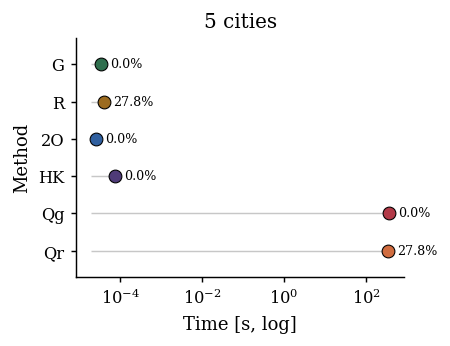

,label,method
0,G,Greedy
1,R,Random initialized
2,2O,2-opt from greedy
3,HK,Held-Karp
4,Qg,Regular QAOA from greedy
5,Qr,Regular QAOA from random


In [14]:
plot_df = summary.copy()
plot_df["runtime_for_plot"] = plot_df["time_sec"].clip(lower=1e-8)

label_map = {
    "Greedy": "G",
    "Random initialized": "R",
    "2-opt from greedy": "2O",
    "Held-Karp": "HK",
    "Regular QAOA from greedy": "Qg",
    "Regular QAOA from random": "Qr",
}
color_map = {
    "Greedy": "#2f6f4e",
    "Random initialized": "#9c6b1f",
    "2-opt from greedy": "#2f5f9f",
    "Held-Karp": "#4f3b78",
    "Regular QAOA from greedy": "#b23a48",
    "Regular QAOA from random": "#d06c3f",
}

plot_df["label"] = plot_df["algorithm"].map(label_map)
plot_df["lane"] = np.arange(len(plot_df))[::-1]
method_colors = plot_df["algorithm"].map(color_map)
x0 = plot_df["runtime_for_plot"].min() * 0.75

fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)

for color, (_, row) in zip(method_colors, plot_df.iterrows()):
    ax.hlines(row["lane"], x0, row["runtime_for_plot"], color="0.78", linewidth=0.8, zorder=1)
    ax.scatter(row["runtime_for_plot"], row["lane"], s=50, color=color, edgecolor="black", linewidth=0.6, zorder=3)
    ax.annotate(f"{row['gap_percent']:.1f}%", (row["runtime_for_plot"], row["lane"]), xytext=(5, 0), textcoords="offset points", va="center", fontsize=7)

ax.set_xscale("log")
ax.set_yticks(plot_df["lane"], plot_df["label"])
ax.set_ylim(-0.7, len(plot_df) - 0.3)
ax.set_title(f"{N_CITIES} cities")
ax.set_xlabel("Time [s, log]")
ax.set_ylabel("Method")
polish_axes(ax)
plt.show()

pd.DataFrame({"label": plot_df["label"], "method": plot_df["algorithm"]})


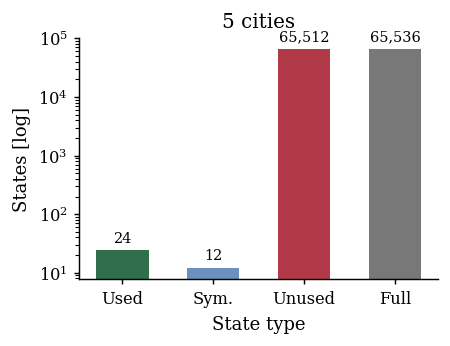

In [15]:
state_counts = pd.Series({
    "Used": len(valid_space),
    "Sym.": SYMMETRY_REDUCED_TOURS,
    "Unused": len(invalid_space),
    "Full": len(space_df),
})
if not SHOW_SYMMETRIC_TSP_COUNT:
    state_counts = state_counts.drop("Sym.")

fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
bar_colors = ["#2f6f4e", "#6c8fbf", "#b23a48", "#787878"] if SHOW_SYMMETRIC_TSP_COUNT else ["#2f6f4e", "#b23a48", "#787878"]
bars = ax.bar(state_counts.index, state_counts.values, color=bar_colors, width=0.58)
ax.set_yscale("log")
ax.set_title(f"{N_CITIES} cities")
ax.set_xlabel("State type")
ax.set_ylabel("States [log]")
ax.bar_label(bars, labels=[f"{int(v):,}" for v in state_counts.values], padding=3, fontsize=8)
polish_axes(ax)
plt.show()


## Notes

- `G` is QAOA initialized from the greedy tour.
- `R` is QAOA initialized from the random valid tour.
- The QAOA optimizer iteration count is intentionally small here so that the five-city full-space notebook remains runnable.

# Classical Diagnostics

These plots tell a different story from runtime-vs-gap: where the heuristics sit in the complete tour-cost landscape, how sensitive they are to the random city geometry, and how 2-opt descends from its initial route.

In [16]:
import itertools


def all_fixed_start_tours(n_cities=N_CITIES, start=START):
    cities = [city for city in range(n_cities) if city != start]
    return [[start] + list(perm) + [start] for perm in itertools.permutations(cities)]


def traced_two_opt(tsp, initial_tour):
    tour = initial_tour[:]
    best_cost = tsp.tour_cost(tour)
    trace = [{"step": 0, "cost": best_cost, "move": "initial", "tour": tour[:]}]
    step = 0
    improved = True

    while improved:
        improved = False
        for i in range(1, tsp.n_locations - 1):
            for j in range(i + 1, tsp.n_locations):
                if j - i == 1:
                    continue

                candidate = tour[:]
                candidate[i:j] = reversed(candidate[i:j])
                candidate_cost = tsp.tour_cost(candidate)

                if candidate_cost < best_cost:
                    tour = candidate
                    best_cost = candidate_cost
                    step += 1
                    improved = True
                    trace.append({
                        "step": step,
                        "cost": best_cost,
                        "move": f"reverse [{i}:{j})",
                        "tour": tour[:],
                    })

    return pd.DataFrame(trace)


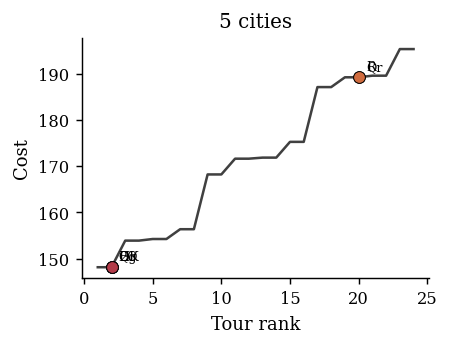

,tour,cost,rank
0,0 -> 2 -> 3 -> 1 -> 4 -> 0,148.11991,1
1,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.11991,2
2,0 -> 4 -> 3 -> 1 -> 2 -> 0,153.88799,3
3,0 -> 2 -> 1 -> 3 -> 4 -> 0,153.88799,4
4,0 -> 2 -> 4 -> 1 -> 3 -> 0,154.23797,5
5,0 -> 3 -> 1 -> 4 -> 2 -> 0,154.23797,6
6,0 -> 2 -> 4 -> 3 -> 1 -> 0,156.36049,7
7,0 -> 1 -> 3 -> 4 -> 2 -> 0,156.36049,8


In [17]:
all_tours = all_fixed_start_tours()
landscape = pd.DataFrame({
    "tour": [" -> ".join(map(str, tour)) for tour in all_tours],
    "cost": [tsp.tour_cost(tour) for tour in all_tours],
}).sort_values("cost").reset_index(drop=True)
landscape["rank"] = np.arange(1, len(landscape) + 1)

markers = summary[["algorithm", "cost"]].copy()
markers = markers[np.isfinite(markers["cost"])]
markers["rank"] = markers["cost"].apply(lambda cost: int((landscape["cost"] <= cost + 1e-9).sum()))

fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
ax.plot(landscape["rank"], landscape["cost"], color="0.25", linewidth=1.4)

marker_map = {
    "Greedy": ("#2f6f4e", "G"),
    "Random initialized": ("#9c6b1f", "R"),
    "2-opt from greedy": ("#2f5f9f", "2O"),
    "Held-Karp": ("#4f3b78", "HK"),
    "Regular QAOA from greedy": ("#b23a48", "Qg"),
    "Regular QAOA from random": ("#d06c3f", "Qr"),
}

for _, row in markers.iterrows():
    color, label = marker_map.get(row["algorithm"], ("black", row["algorithm"]))
    ax.scatter(row["rank"], row["cost"], s=42, color=color, edgecolor="black", linewidth=0.5, zorder=3)
    ax.annotate(label, (row["rank"], row["cost"]), xytext=(4, 4), textcoords="offset points", fontsize=7)

ax.set_title(f"{N_CITIES} cities")
ax.set_xlabel("Tour rank")
ax.set_ylabel("Cost")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

display(landscape.head(8).round(5))


C:\Users\Jogga\AppData\Local\Temp\ipykernel_17244\2426088057.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=["G", "2O"], widths=0.45, patch_artist=True, showfliers=False)


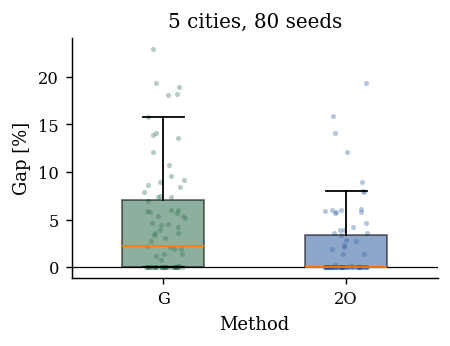

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
2-opt,80.0,2.129,3.908,-0.0,0.0,0.000,3.419,19.401
Greedy,80.0,4.457,5.658,0.0,0.0,2.203,7.078,22.922


In [18]:
seed_rows = []
for seed in range(80):
    seed_tsp = TSP(n_locations=N_CITIES, seed=seed)
    seed_tsp.create_map()
    seed_tsp.compute_distance_matrix()

    greedy_tour = seed_tsp.greedy_search(start=START)
    greedy_cost = seed_tsp.tour_cost(greedy_tour)
    _, two_opt_cost = seed_tsp.two_opt(initial_tour=greedy_tour)
    _, opt_cost = seed_tsp.held_karp(start=START)

    seed_rows.extend([
        {"seed": seed, "method": "Greedy", "gap_percent": 100 * (greedy_cost - opt_cost) / opt_cost},
        {"seed": seed, "method": "2-opt", "gap_percent": 100 * (two_opt_cost - opt_cost) / opt_cost},
    ])

seed_gaps = pd.DataFrame(seed_rows)

fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
data = [
    seed_gaps.loc[seed_gaps["method"] == "Greedy", "gap_percent"],
    seed_gaps.loc[seed_gaps["method"] == "2-opt", "gap_percent"],
]
box = ax.boxplot(data, labels=["G", "2O"], widths=0.45, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], ["#2f6f4e", "#2f5f9f"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

rng = np.random.default_rng(SEED)
for x, method, color in [(1, "Greedy", "#2f6f4e"), (2, "2-opt", "#2f5f9f")]:
    y = seed_gaps.loc[seed_gaps["method"] == method, "gap_percent"].to_numpy()
    jitter = rng.uniform(-0.12, 0.12, len(y))
    ax.scatter(np.full(len(y), x) + jitter, y, s=8, color=color, alpha=0.35, linewidth=0)

ax.axhline(0, color="black", linewidth=0.7)
ax.set_title(f"{N_CITIES} cities, 80 seeds")
ax.set_xlabel("Method")
ax.set_ylabel("Gap [%]")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

display(seed_gaps.groupby("method")["gap_percent"].describe().round(3))


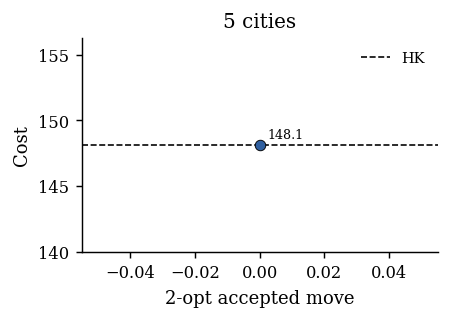

,step,cost,move,tour
0,0,148.11991,initial,0 -> 4 -> 1 -> 3 -> 2 -> 0


In [19]:
trace = traced_two_opt(tsp, greedy_row["tour"])

fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)
ax.step(trace["step"], trace["cost"], where="post", color="#2f5f9f", linewidth=1.8)
ax.scatter(trace["step"], trace["cost"], s=34, color="#2f5f9f", edgecolor="black", linewidth=0.5, zorder=3)
ax.axhline(best_known, color="black", linestyle="--", linewidth=0.9, label="HK")

for _, row in trace.iterrows():
    ax.annotate(f"{row['cost']:.1f}", (row["step"], row["cost"]), xytext=(4, 4), textcoords="offset points", fontsize=7)

ax.set_title(f"{N_CITIES} cities")
ax.set_xlabel("2-opt accepted move")
ax.set_ylabel("Cost")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

display(trace.assign(tour=lambda df: df["tour"].apply(lambda tour: " -> ".join(map(str, tour)))).round(5))


## QAOA probability landscape

This plot compares three full-space QAOA initializations. `S` is the standard preparation: start in `|0...0>` and apply Hadamard gates to all qubits, giving a uniform superposition over the full binary space. `G` starts from the greedy tour, and `R` starts from a random valid tour.

The horizontal axis is the cost of a valid tour. Each circle is one valid tour reached by the final QAOA state, and circle area is proportional to its probability. The dashed vertical line is the Held-Karp optimum. Invalid probability is intentionally not written inside the figure; it is reported in the table below.

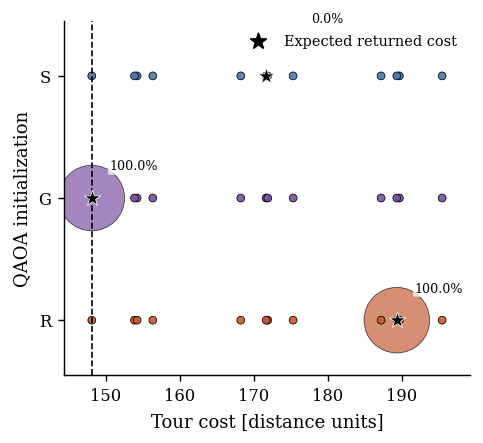

,run,init,valid_probability,invalid_probability
0,G,greedy route,1.000000,0.000000
1,R,random valid route,1.000000,0.000000
2,S,standard superposition,0.000367,0.999633


,run,tour,cost,probability
19,G,0 -> 4 -> 1 -> 3 -> 2 -> 0,148.11991,1.0
8,G,0 -> 2 -> 3 -> 1 -> 4 -> 0,148.11991,0.0
10,G,0 -> 2 -> 4 -> 1 -> 3 -> 0,154.23797,0.0
13,G,0 -> 3 -> 1 -> 4 -> 2 -> 0,154.23797,0.0
5,G,0 -> 1 -> 4 -> 3 -> 2 -> 0,171.65137,0.0
9,G,0 -> 2 -> 3 -> 4 -> 1 -> 0,171.65137,0.0
16,G,0 -> 3 -> 4 -> 1 -> 2 -> 0,175.29691,0.0
7,G,0 -> 2 -> 1 -> 4 -> 3 -> 0,175.29691,0.0
6,G,0 -> 2 -> 1 -> 3 -> 4 -> 0,153.88799,0.0
22,G,0 -> 4 -> 3 -> 1 -> 2 -> 0,153.88799,0.0


In [20]:
STANDARD_QAOA_MAXITER = 25
STANDARD_QAOA_SHOTS = 12


def full_probability_frame(label, qaoa, probabilities):
    records = []
    for bitstring, probability in probabilities.items():
        x = qaoa._bitstring_to_one_hot(bitstring)
        valid = bool(np.all(x.sum(axis=1) == 1) and np.all(x.sum(axis=0) == 1))
        tour = None
        cost = np.nan
        if valid:
            tour = qaoa._one_hot_to_tour(x)
            cost = tsp.tour_cost(tour)
        records.append({
            "run": label,
            "bitstring": bitstring,
            "probability": float(probability),
            "valid": valid,
            "tour": None if tour is None else " -> ".join(map(str, tour)),
            "cost": cost,
        })
    return pd.DataFrame(records)


def qaoa_probability_frame(label, row):
    decoder = QAOA(tsp=tsp, layers=QAOA_LAYERS, fixed_start=True, compressed_basis=False, seed=SEED)
    return full_probability_frame(label, decoder, row["qaoa_probabilities"])


def run_standard_superposition_qaoa():
    qaoa = QAOA(
        tsp=tsp,
        layers=QAOA_LAYERS,
        initial_route=None,
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
    )
    qaoa.build_HC()
    t0 = time.perf_counter()
    result = qaoa._optimize(maxiter=STANDARD_QAOA_MAXITER, shots=STANDARD_QAOA_SHOTS)
    runtime = time.perf_counter() - t0
    theta = result["theta"]
    final_state = Statevector.from_instruction(qaoa.processor(theta[:QAOA_LAYERS], theta[QAOA_LAYERS:]))
    probs = full_probability_frame("S", qaoa, final_state.probabilities_dict())
    return qaoa, result, probs, runtime


standard_qaoa, standard_result, standard_probs, standard_time = run_standard_superposition_qaoa()

qaoa_prob_df = pd.concat([
    standard_probs,
    qaoa_probability_frame("G", qaoa_greedy_row),
    qaoa_probability_frame("R", qaoa_random_row),
], ignore_index=True)

valid_qaoa = qaoa_prob_df[qaoa_prob_df["valid"]].copy()
valid_by_tour = (
    valid_qaoa
    .groupby(["run", "tour", "cost"], as_index=False)["probability"]
    .sum()
    .sort_values(["run", "probability"], ascending=[True, False])
)
qaoa_landscape_stats = (
    qaoa_prob_df
    .assign(invalid_probability=lambda df: np.where(df["valid"], 0.0, df["probability"]))
    .groupby("run", as_index=False)
    .agg(
        valid_probability=("valid", lambda valid: float(qaoa_prob_df.loc[valid.index, "probability"][valid].sum())),
        invalid_probability=("invalid_probability", "sum"),
    )
)
qaoa_landscape_stats["init"] = qaoa_landscape_stats["run"].map({
    "S": "standard superposition",
    "G": "greedy route",
    "R": "random valid route",
})

fig, ax = plt.subplots(figsize=(3.6, 3.3), constrained_layout=True)



palette = {"S": "#4c78a8", "G": "#7b4fa3", "R": "#c45a32"}
ypos = {"S": 2.0, "G": 1.0, "R": 0.0}
label_offsets = {
    "S": (10, 28),
    "G": (10, 14),
    "R": (10, 14),
}

for run in ["S", "G", "R"]:
    sub = valid_by_tour[valid_by_tour["run"] == run]
    if sub.empty:
        continue

    size = 18 + 1300 * sub["probability"].to_numpy()

    ax.scatter(
        sub["cost"],
        np.full(len(sub), ypos[run]),
        s=size,
        color=palette[run],
        alpha=0.68,
        edgecolor="black",
        linewidth=0.45,
    )

    top = sub.nlargest(1, "probability").iloc[0]
    expected_cost = np.sum(sub["cost"] * sub["probability"]) / np.sum(sub["probability"])

    ax.scatter(
        [expected_cost],
        [ypos[run]],
        marker="*",
        s=90,
        color="black",
        edgecolor="white",
        linewidth=0.45,
        zorder=8,
    )

    ax.annotate(
        f"{100 * top['probability']:.1f}%",
        (top["cost"], ypos[run]),
        xytext=label_offsets[run],
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
        zorder=10,
        clip_on=False,
    )

ax.axvline(best_known, color="black", linestyle="--", linewidth=0.9)
ax.scatter([], [], marker="*", s=80, color="black", label="Expected returned cost")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper right",
)

ax.set_xlabel("Tour cost [distance units]")
ax.set_ylabel("QAOA initialization")
ax.set_yticks([ypos["R"], ypos["G"], ypos["S"]], ["R", "G", "S"])
ax.set_ylim(-0.45, 2.45)
ax.margins(x=0.08, y=0.22)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

display(qaoa_landscape_stats[["run", "init", "valid_probability", "invalid_probability"]].round(6))
display(valid_by_tour.head(15).round({"cost": 5, "probability": 5}))


The key reading is whether probability mass is concentrated near the dashed optimum line, and whether the initialization wastes mass outside the valid TSP subspace. `S` is the fairest "standard QAOA" reference, but for the one-hot TSP encoding it usually spreads over many invalid bitstrings. `G` and `R` begin inside the valid route sector. With the Grover mixer, probability can still move outside that sector because the mixer acts globally on the full binary space.

In [21]:
def probability_stats(label, frame):
    valid = frame[frame["valid"]].copy()
    valid_mass = float(valid["probability"].sum())
    invalid_mass = 1.0 - valid_mass
    if valid_mass > 0:
        expected_valid_cost = float(np.dot(valid["probability"], valid["cost"]) / valid_mass)
        opt_probability = float(valid.loc[np.isclose(valid["cost"], best_known), "probability"].sum())
        best_valid_cost = float(valid["cost"].min())
    else:
        expected_valid_cost = np.nan
        opt_probability = 0.0
        best_valid_cost = np.inf
    return {
        "run": label,
        "valid_probability": valid_mass,
        "invalid_probability": invalid_mass,
        "expected_valid_cost": expected_valid_cost,
        "expected_valid_gap_percent": 100 * (expected_valid_cost - best_known) / best_known,
        "best_valid_cost": best_valid_cost,
        "opt_probability": opt_probability,
    }

standard_compare = pd.DataFrame([
    probability_stats("S", qaoa_prob_df[qaoa_prob_df["run"] == "S"]),
    probability_stats("G", qaoa_prob_df[qaoa_prob_df["run"] == "G"]),
    probability_stats("R", qaoa_prob_df[qaoa_prob_df["run"] == "R"]),
])

display(standard_compare.round(6))


,run,valid_probability,invalid_probability,expected_valid_cost,expected_valid_gap_percent,best_valid_cost,opt_probability
0,S,0.000367,0.999633,171.614527,15.861887,148.119914,0.000031
1,G,1.000000,0.000000,148.119914,0.000000,148.119914,1.000000
2,R,1.000000,0.000000,189.293900,27.797738,148.119914,0.000000


## Full-space mixer comparison

This test compares QAOA mixers against three initializations: `S` is the standard uniform superposition, `G` starts from the greedy tour, and `R` starts from a random valid tour. The mixers are `grover`, `x`, and `xy`.

The figure is a compact comparison map. Each panel uses the same rows and columns, but measures a different outcome: valid probability, optimum probability, expected valid-tour gap, and optimization time.


In [22]:
MIXER_TEST_LAYERS = 1
MIXER_TEST_MAXITER = 8
MIXER_TEST_SHOTS = 200
MIXER_TEST_MIXERS = ["grover", "x", "xy"]
MIXER_TEST_INIT_ORDER = ["S", "G", "R"]
MIXER_TEST_INITS = {
    "S": None,
    "G": greedy_row["tour"],
    "R": random_row["tour"],
}


def mixer_state_summary(qaoa, theta, opt_cost):
    state = Statevector.from_instruction(qaoa.processor(theta[:qaoa.layers], theta[qaoa.layers:]))
    valid_mass = 0.0
    opt_mass = 0.0
    expected_valid_cost = 0.0
    best_valid_cost = float("inf")
    valid_states = 0

    for bitstring, probability in state.probabilities_dict().items():
        x = qaoa._bitstring_to_one_hot(bitstring)
        valid = bool(np.all(x.sum(axis=1) == 1) and np.all(x.sum(axis=0) == 1))
        if not valid:
            continue

        probability = float(probability)
        tour = qaoa._one_hot_to_tour(x)
        cost = qaoa.tsp.tour_cost(tour)

        valid_states += 1
        valid_mass += probability
        expected_valid_cost += probability * cost
        best_valid_cost = min(best_valid_cost, cost)

        if np.isclose(cost, opt_cost):
            opt_mass += probability

    if valid_mass > 0:
        expected_valid_cost /= valid_mass
    else:
        expected_valid_cost = np.nan

    return {
        "valid_states": valid_states,
        "valid_probability": valid_mass,
        "invalid_probability": 1.0 - valid_mass,
        "opt_probability": opt_mass,
        "expected_valid_cost": expected_valid_cost,
        "best_valid_cost": best_valid_cost,
    }


def run_mixer_test_case(init_label, init_tour, mixer):
    initial_route = None if init_tour is None else fixed_start_one_hot_encoding(init_tour, start=START)
    qaoa = QAOA(
        tsp=tsp,
        layers=MIXER_TEST_LAYERS,
        initial_route=initial_route,
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=mixer,
    )
    qaoa.build_HC()

    t0 = time.perf_counter()
    result = qaoa._optimize(maxiter=MIXER_TEST_MAXITER, shots=MIXER_TEST_SHOTS)
    runtime = time.perf_counter() - t0
    state_summary = mixer_state_summary(qaoa, result["theta"], best_known)

    return {
        "init": init_label,
        "mixer": mixer,
        **state_summary,
        "expected_valid_gap_percent": 100 * (state_summary["expected_valid_cost"] - best_known) / best_known,
        "sampled_valid_fraction": float(result["valid_fraction"]),
        "sampled_best_cost": float(result["best_cost"]),
        "energy": float(result["energy"]),
        "time_sec": runtime,
    }


mixer_rows = []
for init_label, init_tour in MIXER_TEST_INITS.items():
    for mixer in MIXER_TEST_MIXERS:
        print(f"Running init={init_label}, mixer={mixer} ...")
        mixer_rows.append(run_mixer_test_case(init_label, init_tour, mixer))

mixer_test_df = pd.DataFrame(mixer_rows)
mixer_test_df["valid_probability_percent"] = 100 * mixer_test_df["valid_probability"]
mixer_test_df["invalid_probability_percent"] = 100 * mixer_test_df["invalid_probability"]
mixer_test_df["opt_probability_percent"] = 100 * mixer_test_df["opt_probability"]

cols = [
    "init", "mixer", "valid_probability_percent", "opt_probability_percent",
    "expected_valid_gap_percent", "sampled_best_cost", "sampled_valid_fraction", "time_sec",
]
display(mixer_test_df[cols].round(5))


Running init=S, mixer=grover ...
Running init=S, mixer=x ...
Running init=S, mixer=xy ...
Running init=G, mixer=grover ...
Running init=G, mixer=x ...
Running init=G, mixer=xy ...
Running init=R, mixer=grover ...
Running init=R, mixer=x ...
Running init=R, mixer=xy ...


,init,mixer,valid_probability_percent,opt_probability_percent,expected_valid_gap_percent,sampled_best_cost,sampled_valid_fraction,time_sec
0,S,grover,0.03659,0.00308,15.95598,inf,0.000,72.25845
1,S,x,0.15135,0.01076,13.85716,inf,0.000,49.87202
2,S,xy,0.02918,0.00085,12.54381,inf,0.000,49.49491
3,G,grover,100.00000,100.00000,0.00000,148.11991,1.000,70.53278
4,G,x,99.87107,99.87107,-0.00000,148.11991,1.000,46.75427
5,G,xy,92.81021,0.00000,28.03378,189.64388,0.925,3.21036
6,R,grover,100.00000,0.00000,27.79774,189.29390,1.000,1074.96402
7,R,x,99.86219,0.00000,27.79774,189.29390,1.000,26.78795
8,R,xy,98.88819,0.00000,27.79752,189.29390,1.000,1.62734


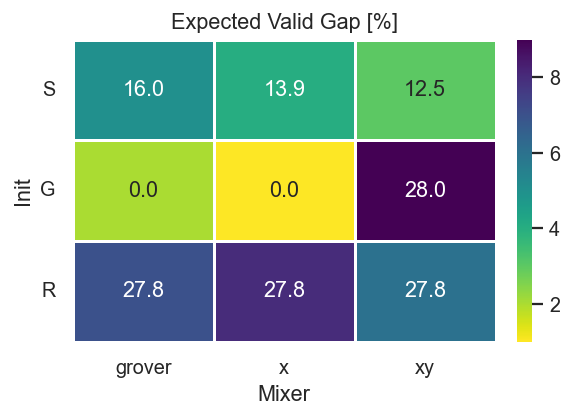

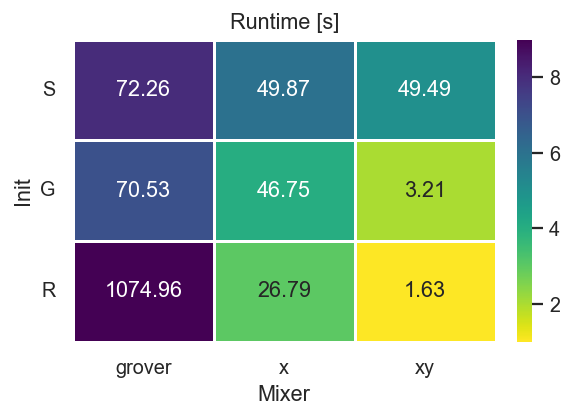

In [61]:
import seaborn as sns


def mixer_metric_pivot(metric):
    return (
        mixer_test_df
        .pivot(index="init", columns="mixer", values=metric)
        .loc[MIXER_TEST_INIT_ORDER, MIXER_TEST_MIXERS]
    )


gap_pivot = mixer_metric_pivot("expected_valid_gap_percent").clip(lower=0)
time_pivot = mixer_metric_pivot("time_sec")


def rank_for_coloring(pivot, lower_is_better=True):
    flat = pivot.stack()

    if lower_is_better:
        ranks = flat.rank(method="dense", ascending=True)
    else:
        ranks = flat.rank(method="dense", ascending=False)

    return ranks.unstack().loc[pivot.index, pivot.columns]


gap_rank = rank_for_coloring(gap_pivot, lower_is_better=True)
time_rank = rank_for_coloring(time_pivot, lower_is_better=True)

sns.set_theme(context="notebook", style="white", font_scale=1.0)

fig, ax = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)

sns.heatmap(
    gap_rank,
    ax=ax,
    annot=gap_pivot,
    fmt=".1f",
    cmap="viridis_r",
    linewidths=0.7,
    linecolor="white",
)

ax.set_title("Expected Valid Gap [%]")
ax.set_xlabel("Mixer")
ax.set_ylabel("Init")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.show()


fig, ax = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)

sns.heatmap(
    time_rank,
    ax=ax,
    annot=time_pivot,
    fmt=".2f",
    cmap="viridis_r",
    linewidths=0.7,
    linecolor="white",
)

ax.set_title("Runtime [s]")
ax.set_xlabel("Mixer")
ax.set_ylabel("Init")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.show()



In [62]:
from scipy.optimize import minimize
import seaborn as sns


CONV_LAYERS = 1
CONV_MAXITER = 35
CONV_MIXERS = ["grover", "x", "xy"]
CONV_INITS = {
    "S": None,
    "G": greedy_row["tour"],
    "R": random_row["tour"],
}


def conv_initial_route(init_tour):
    return None if init_tour is None else fixed_start_one_hot_encoding(init_tour, start=START)


def run_qaoa_convergence(init_label, init_tour, mixer, layers=CONV_LAYERS, maxiter=CONV_MAXITER):
    qaoa = QAOA(
        tsp=tsp,
        layers=layers,
        initial_route=conv_initial_route(init_tour),
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=mixer,
    )
    qaoa.build_HC()

    rng = np.random.default_rng(SEED)
    theta0 = np.concatenate([
        rng.uniform(0, 2 * np.pi, layers),
        rng.uniform(0, np.pi, layers),
    ])

    trace = []

    def objective(theta):
        energy = qaoa._energy(theta)
        trace.append(float(energy))
        return energy

    t0 = time.perf_counter()
    result = minimize(
        objective,
        theta0,
        method="COBYLA",
        options={"maxiter": maxiter},
    )
    runtime = time.perf_counter() - t0

    trace_df = pd.DataFrame({
        "eval": np.arange(1, len(trace) + 1),
        "energy": trace,
        "best_energy": np.minimum.accumulate(trace),
        "init": init_label,
        "mixer": mixer,
        "case": f"{init_label}/{mixer}",
    })

    summary = mixer_state_summary(qaoa, result.x, best_known)
    summary.update({
        "init": init_label,
        "mixer": mixer,
        "case": f"{init_label}/{mixer}",
        "final_energy": float(result.fun),
        "best_trace_energy": float(np.min(trace)),
        "time_sec": runtime,
        "valid_probability_percent": 100 * summary["valid_probability"],
        "opt_probability_percent": 100 * summary["opt_probability"],
        "expected_valid_gap_percent": 100 * (summary["expected_valid_cost"] - best_known) / best_known,
    })

    return trace_df, summary


conv_traces = []
conv_rows = []

for init_label, init_tour in CONV_INITS.items():
    for mixer in CONV_MIXERS:
        print(f"Tracing init={init_label}, mixer={mixer} ...")
        trace_df, row = run_qaoa_convergence(init_label, init_tour, mixer)
        conv_traces.append(trace_df)
        conv_rows.append(row)

conv_trace_df = pd.concat(conv_traces, ignore_index=True)
conv_summary_df = pd.DataFrame(conv_rows)

display(
    conv_summary_df[
        [
            "init", "mixer", "best_trace_energy", "expected_valid_gap_percent",
            "valid_probability_percent", "opt_probability_percent", "time_sec",
        ]
    ].round(4)
)


Tracing init=S, mixer=grover ...
Tracing init=S, mixer=x ...
Tracing init=S, mixer=xy ...
Tracing init=G, mixer=grover ...
Tracing init=G, mixer=x ...
Tracing init=G, mixer=xy ...
Tracing init=R, mixer=grover ...
Tracing init=R, mixer=x ...
Tracing init=R, mixer=xy ...


,init,mixer,best_trace_energy,expected_valid_gap_percent,valid_probability_percent,opt_probability_percent,time_sec
0,S,grover,5919.7365,15.9682,0.0366,0.0030,192.2672
1,S,x,4509.1143,14.1114,0.2013,0.0168,131.4628
2,S,xy,5898.2218,14.2371,0.0340,0.0016,152.7794
3,G,grover,148.1199,0.0000,100.0000,100.0000,202.0966
4,G,x,148.1199,0.0000,100.0000,100.0000,172.0195
5,G,xy,189.6439,28.0340,100.0000,0.0000,7.7678
6,R,grover,189.2939,27.7977,100.0000,0.0000,200.3272
7,R,x,189.2939,27.7977,100.0000,0.0000,157.2547
8,R,xy,189.2939,27.7977,100.0000,0.0000,8.0824


Tracing mixer=grover, init=S ...
Tracing mixer=grover, init=G ...
Tracing mixer=grover, init=R ...
Tracing mixer=x, init=S ...
Tracing mixer=x, init=G ...
Tracing mixer=x, init=R ...
Tracing mixer=xy, init=S ...
Tracing mixer=xy, init=G ...
Tracing mixer=xy, init=R ...


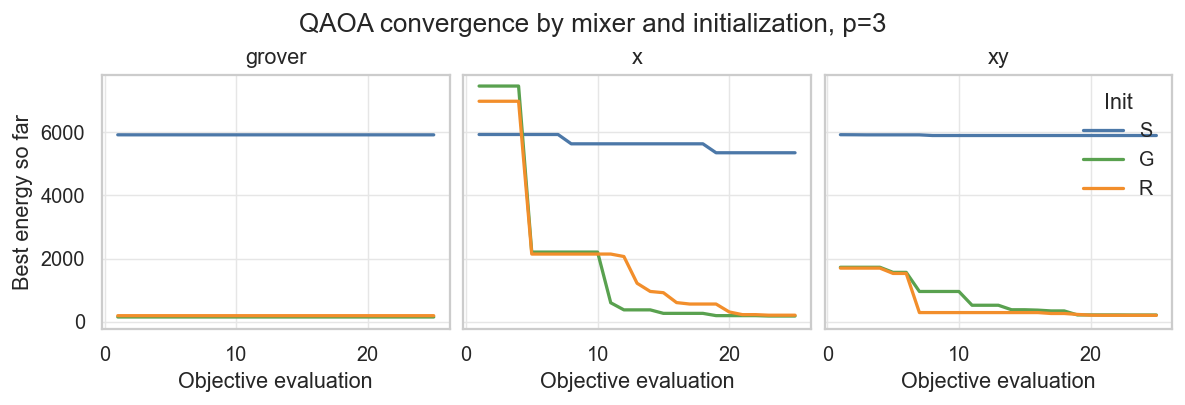

In [ ]:
from scipy.optimize import minimize
import seaborn as sns

QAOA_DEPTH = QAOA_LAYERS
MAX_OPTIMIZER_EVALS = 25

MIXERS_TO_COMPARE = ["grover", "x", "xy"]
INITIALIZATIONS = {
    "S": None,
    "G": greedy_row["tour"],
    "R": random_row["tour"],
}


def initial_route_from_tour(tour):
    return None if tour is None else fixed_start_one_hot_encoding(tour, start=START)


def qaoa_convergence_trace(init_label, init_tour, mixer):
    qaoa = QAOA(
        tsp=tsp,
        layers=QAOA_DEPTH,
        initial_route=initial_route_from_tour(init_tour),
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=mixer,
    )
    qaoa.build_HC()

    rng = np.random.default_rng(SEED)
    theta0 = np.concatenate([
        rng.uniform(0, 2 * np.pi, QAOA_DEPTH),
        rng.uniform(0, np.pi, QAOA_DEPTH),
    ])

    energies = []

    def objective(theta):
        energy = qaoa._energy(theta)
        energies.append(float(energy))
        return energy

    minimize(
        objective,
        theta0,
        method="COBYLA",
        options={"maxiter": MAX_OPTIMIZER_EVALS},
    )

    return pd.DataFrame({
        "eval": np.arange(1, len(energies) + 1),
        "energy": energies,
        "best_energy": np.minimum.accumulate(energies),
        "init": init_label,
        "mixer": mixer,
    })


trace_frames = []

for mixer in MIXERS_TO_COMPARE:
    for init_label, init_tour in INITIALIZATIONS.items():
        print(f"Tracing mixer={mixer}, init={init_label} ...")
        trace_frames.append(qaoa_convergence_trace(init_label, init_tour, mixer))

convergence_df = pd.concat(trace_frames, ignore_index=True)

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.0)

fig, ax = plt.subplots(figsize=(4.2, 3.0), constrained_layout=True)


colors = {
    "S": "#4c78a8",
    "G": "#59a14f",
    "R": "#f28e2b",
}

mixer = "x"
sub_mixer = convergence_df[convergence_df["mixer"] == mixer]

for init_label in ["S", "G", "R"]:
    sub = sub_mixer[sub_mixer["init"] == init_label]
    ax.plot(
        sub["eval"],
        sub["best_energy"],
        linewidth=1.8,
        color=colors[init_label],
        label=init_label,
    )

ax.set_title("X mixer")
ax.set_xlabel("Objective evaluation")
ax.set_ylabel("Best energy so far")
ax.grid(True, color="0.9", linewidth=0.8)
ax.legend(frameon=False, title="Init", loc="upper right")


fig.suptitle(f"QAOA convergence by mixer and initialization, p={QAOA_DEPTH}")
plt.show()


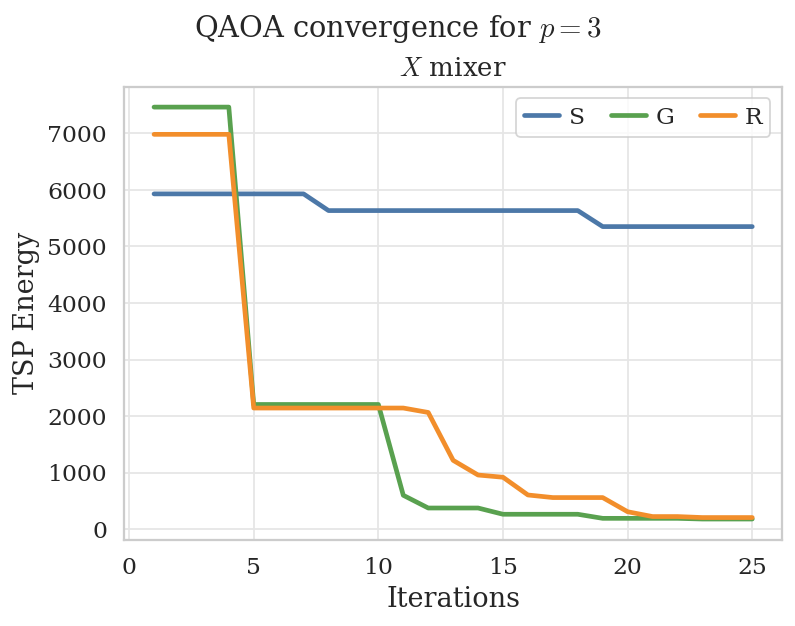

In [86]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 14,
})



fig, ax = plt.subplots(figsize=(6.0, 4.7), constrained_layout=True)


colors = {
    "S": "#4c78a8",
    "G": "#59a14f",
    "R": "#f28e2b",
}

mixer = "x"
sub_mixer = convergence_df[convergence_df["mixer"] == mixer]

for init_label in ["S", "G", "R"]:
    sub = sub_mixer[sub_mixer["init"] == init_label]
    ax.plot(
        sub["eval"],
        sub["best_energy"],
        linewidth=2.6,
        color=colors[init_label],
        label=init_label,
    )



ax.set_title(r"$X$ mixer", fontsize=14.5)
ax.set_xlabel(r"Iterations", fontsize=15)
ax.set_ylabel(r"TSP Energy", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.grid(True, color="0.9", linewidth=1.0)

ax.legend(
    loc="upper right",
    ncol=3,
    frameon=True,
    prop={"size": 13},
    columnspacing=1.1,
    handlelength=1.5,
    handletextpad=0.4,
    borderpad=0.35,
)

fig.suptitle(rf"QAOA convergence for $p={QAOA_DEPTH}$", fontsize=16)
plt.show()



init=S: computing row 1/21
init=S: computing row 2/21
init=S: computing row 3/21
init=S: computing row 4/21
init=S: computing row 5/21
init=S: computing row 6/21
init=S: computing row 7/21
init=S: computing row 8/21
init=S: computing row 9/21
init=S: computing row 10/21
init=S: computing row 11/21
init=S: computing row 12/21
init=S: computing row 13/21
init=S: computing row 14/21
init=S: computing row 15/21
init=S: computing row 16/21
init=S: computing row 17/21
init=S: computing row 18/21
init=S: computing row 19/21
init=S: computing row 20/21
init=S: computing row 21/21
init=S: min energy = 5348.5493 at beta/pi = -0.700, gamma/pi = 0.900
init=G: computing row 1/21
init=G: computing row 2/21
init=G: computing row 3/21
init=G: computing row 4/21
init=G: computing row 5/21
init=G: computing row 6/21
init=G: computing row 7/21
init=G: computing row 8/21
init=G: computing row 9/21
init=G: computing row 10/21
init=G: computing row 11/21
init=G: computing row 12/21
init=G: computing row 13/

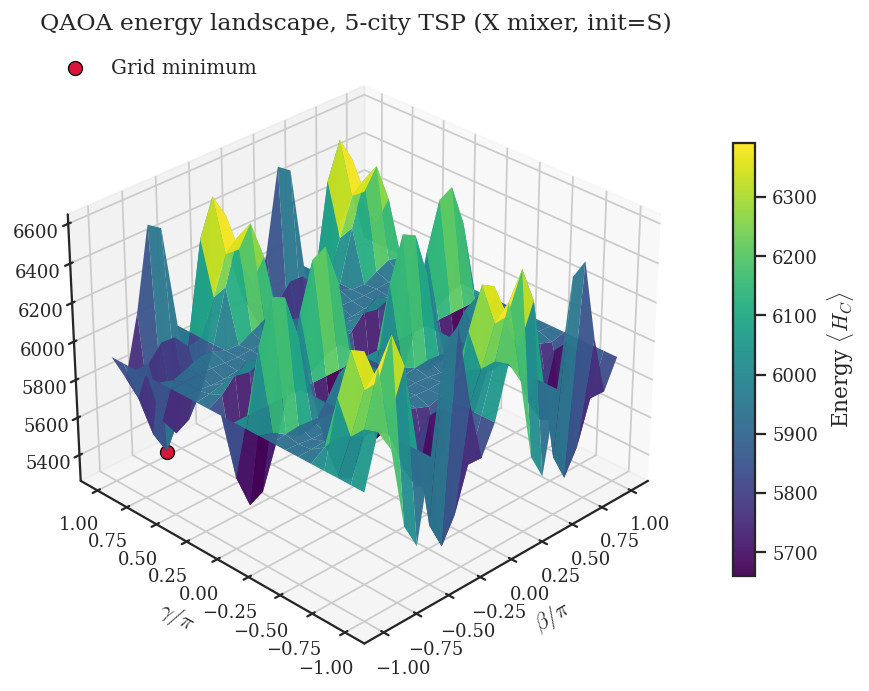

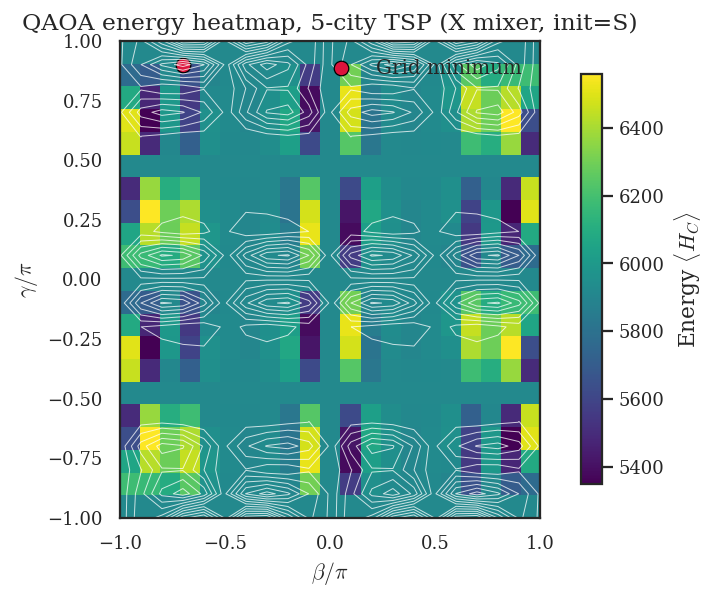

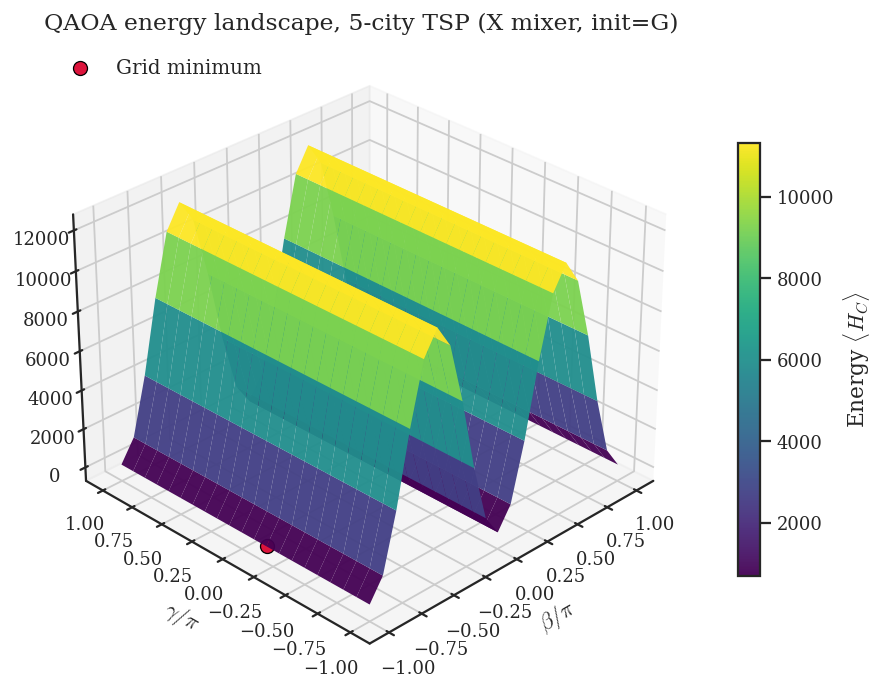

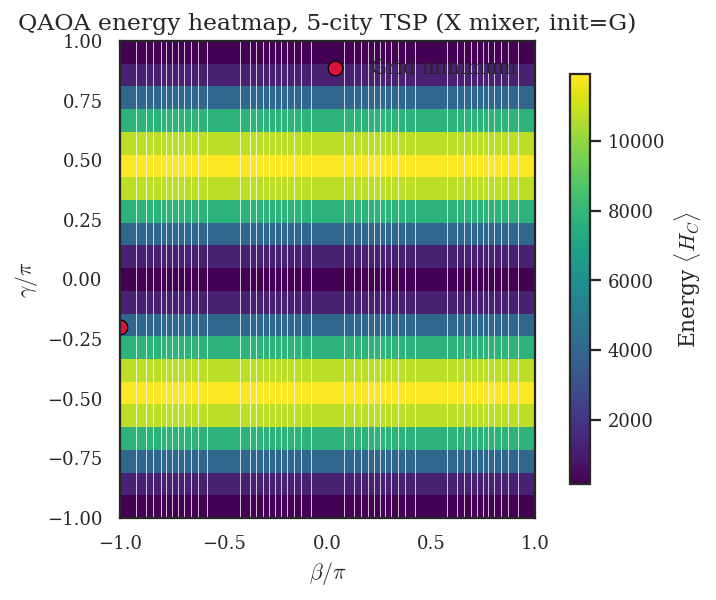

In [96]:
# Fast QAOA energy landscapes for TSP: standard and greedy initializations
# Produces four figures: S 3D, S 2D, G 3D, G 2D.

LANDSCAPE_CITIES = 5
LANDSCAPE_MIXER = "x"
LANDSCAPE_GRID = 21
LANDSCAPE_INITS = ["S", "G"]

landscape_tsp = TSP(n_locations=LANDSCAPE_CITIES, seed=SEED)
landscape_tsp.create_map()
landscape_tsp.compute_distance_matrix()
landscape_greedy_tour = landscape_tsp.greedy_search(start=START)

gamma_values = np.linspace(-np.pi, np.pi, LANDSCAPE_GRID)
beta_values = np.linspace(-np.pi, np.pi, LANDSCAPE_GRID)
GAMMA, BETA = np.meshgrid(gamma_values, beta_values)

landscape_results = {}

for init_label in LANDSCAPE_INITS:
    if init_label == "S":
        initial_route = None
    elif init_label == "G":
        initial_route = fixed_start_one_hot_encoding(landscape_greedy_tour, start=START)
    else:
        raise ValueError("Unknown init label.")

    qaoa = QAOA(
        tsp=landscape_tsp,
        layers=1,
        initial_route=initial_route,
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=LANDSCAPE_MIXER,
    )
    qaoa.build_HC()

    energy = np.zeros_like(GAMMA, dtype=float)

    for i, beta in enumerate(beta_values):
        print(f"init={init_label}: computing row {i + 1}/{LANDSCAPE_GRID}")
        for j, gamma in enumerate(gamma_values):
            energy[i, j] = qaoa._energy(np.array([gamma, beta]))

    min_idx = np.unravel_index(np.argmin(energy), energy.shape)
    landscape_results[init_label] = {
        "energy": energy,
        "min_beta": BETA[min_idx] / np.pi,
        "min_gamma": GAMMA[min_idx] / np.pi,
        "min_energy": energy[min_idx],
    }

    print(
        f"init={init_label}: min energy = {energy[min_idx]:.4f} at "
        f"beta/pi = {BETA[min_idx] / np.pi:.3f}, "
        f"gamma/pi = {GAMMA[min_idx] / np.pi:.3f}"
    )


plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
})


def plot_landscape_3d(init_label):
    energy = landscape_results[init_label]["energy"]
    min_beta = landscape_results[init_label]["min_beta"]
    min_gamma = landscape_results[init_label]["min_gamma"]
    min_energy = landscape_results[init_label]["min_energy"]

    fig = plt.figure(figsize=(7.2, 5.2), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(
        BETA / np.pi,
        GAMMA / np.pi,
        energy,
        cmap="viridis",
        linewidth=0,
        antialiased=True,
        alpha=0.95,
    )

    ax.scatter(
        min_beta,
        min_gamma,
        min_energy,
        color="crimson",
        s=60,
        edgecolor="black",
        linewidth=0.7,
        label="Grid minimum",
    )

    ax.set_title(
        rf"QAOA energy landscape, {LANDSCAPE_CITIES}-city TSP "
        rf"({LANDSCAPE_MIXER.upper()} mixer, init={init_label})"
    )
    ax.set_xlabel(r"$\beta/\pi$")
    ax.set_ylabel(r"$\gamma/\pi$")
    ax.set_zlabel("")  # keep energy unit only on colorbar
    ax.tick_params(axis="z", pad=2)

    ax.view_init(elev=30, azim=-135)
    ax.legend(frameon=False, loc="upper left")

    cbar = fig.colorbar(surface, ax=ax, shrink=0.68, pad=0.08)
    cbar.set_label(r"Energy $\langle H_C\rangle$")

    plt.show()


def plot_landscape_heatmap(init_label):
    energy = landscape_results[init_label]["energy"]
    min_beta = landscape_results[init_label]["min_beta"]
    min_gamma = landscape_results[init_label]["min_gamma"]

    fig, ax = plt.subplots(figsize=(5.4, 4.5), constrained_layout=True)

    im = ax.imshow(
        energy,
        origin="lower",
        extent=[
            beta_values.min() / np.pi,
            beta_values.max() / np.pi,
            gamma_values.min() / np.pi,
            gamma_values.max() / np.pi,
        ],
        aspect="auto",
        cmap="viridis",
    )

    ax.contour(
        BETA / np.pi,
        GAMMA / np.pi,
        energy,
        levels=12,
        colors="white",
        linewidths=0.55,
        alpha=0.75,
    )

    ax.scatter(
        min_beta,
        min_gamma,
        s=65,
        color="crimson",
        edgecolor="black",
        linewidth=0.7,
        label="Grid minimum",
    )

    ax.set_title(
        rf"QAOA energy heatmap, {LANDSCAPE_CITIES}-city TSP "
        rf"({LANDSCAPE_MIXER.upper()} mixer, init={init_label})"
    )
    ax.set_xlabel(r"$\beta/\pi$")
    ax.set_ylabel(r"$\gamma/\pi$")

    cbar = fig.colorbar(im, ax=ax, shrink=0.86)
    cbar.set_label(r"Energy $\langle H_C\rangle$")

    ax.legend(frameon=False, loc="upper right")
    plt.show()


for init_label in LANDSCAPE_INITS:
    plot_landscape_3d(init_label)
    plot_landscape_heatmap(init_label)




NameError: name 'min_delta_beta' is not defined

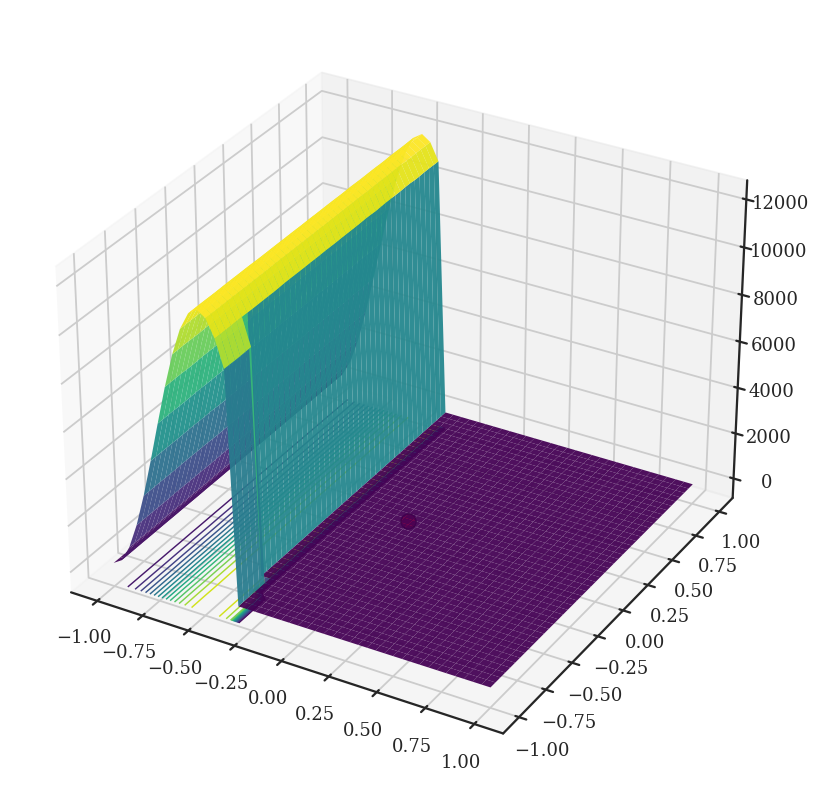

In [93]:

# 3D surface: local QAOA optimizer landscape around the optimized parameters.

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
})

fig = plt.figure(figsize=(8.4, 6.0), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

X = DELTA_BETA / np.pi
Y = DELTA_GAMMA / np.pi
Z = ENERGY_SLICE

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.94,
    rcount=90,
    ccount=90,
)

ax.contour(
    X,
    Y,
    Z,
    zdir="z",
    offset=Z.min() - 0.06 * (Z.max() - Z.min()),
    levels=14,
    cmap="viridis",
    linewidths=0.8,
)

ax.scatter(
    [0],
    [0],
    [landscape_result.fun],
    color="crimson",
    s=70,
    edgecolor="black",
    linewidth=0.7,
    label="Optimizer result",
)

ax.scatter(
    [min_delta_beta],
    [min_delta_gamma],
    [min_energy],
    color="white",
    s=55,
    edgecolor="black",
    linewidth=0.7,
    label="Grid minimum",
)

ax.set_title(
    rf"Local QAOA energy landscape, {LANDSCAPE_CITIES}-city TSP "
    rf"({LANDSCAPE_MIXER.upper()} mixer, init={LANDSCAPE_INIT})"
)
ax.set_xlabel(r"$\Delta\beta_{\ell}/\pi$")
ax.set_ylabel(r"$\Delta\gamma_{\ell}/\pi$")
ax.set_zlabel(r"Penalized energy $\langle H_C \rangle$")

ax.set_zlim(Z.min() - 0.06 * (Z.max() - Z.min()), Z.max())
ax.view_init(elev=31, azim=-132)
ax.legend(frameon=False, loc="upper left")

cbar = fig.colorbar(surface, ax=ax, shrink=0.68, pad=0.08)
cbar.set_label(r"$\langle H_C \rangle$")

fig.suptitle(rf"Energy slice through optimized $p={LANDSCAPE_DEPTH}$ QAOA parameters")
plt.show()


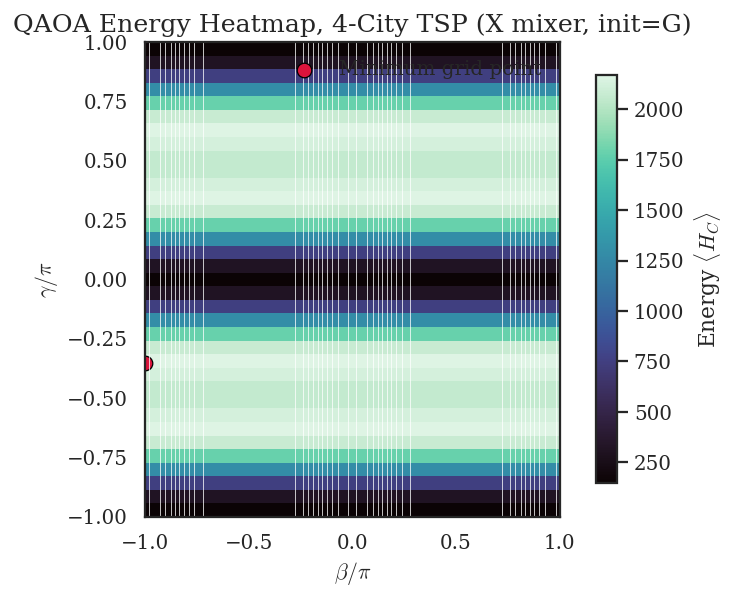

In [ ]:

# 2D contour heatmap: same landscape slice, with optimizer path projection.

fig, ax = plt.subplots(figsize=(6.2, 5.0), constrained_layout=True)

im = ax.imshow(
    ENERGY_SLICE,
    origin="lower",
    extent=[
        delta_beta.min() / np.pi,
        delta_beta.max() / np.pi,
        delta_gamma.min() / np.pi,
        delta_gamma.max() / np.pi,
    ],
    aspect="auto",
    cmap="viridis",
)

contours = ax.contour(
    DELTA_BETA / np.pi,
    DELTA_GAMMA / np.pi,
    ENERGY_SLICE,
    levels=16,
    colors="white",
    linewidths=0.6,
    alpha=0.8,
)

ax.plot(
    trace_df["delta_beta"],
    trace_df["delta_gamma"],
    color="black",
    linewidth=1.1,
    alpha=0.75,
    label="Optimizer path",
)

ax.scatter(
    [0],
    [0],
    color="crimson",
    s=70,
    edgecolor="black",
    linewidth=0.7,
    zorder=5,
    label="Optimizer result",
)

ax.scatter(
    [min_delta_beta],
    [min_delta_gamma],
    color="white",
    s=55,
    edgecolor="black",
    linewidth=0.7,
    zorder=5,
    label="Grid minimum",
)

ax.set_title(
    rf"QAOA energy heatmap near optimum "
    rf"({LANDSCAPE_MIXER.upper()} mixer, init={LANDSCAPE_INIT})"
)
ax.set_xlabel(r"$\Delta\beta_{\ell}/\pi$")
ax.set_ylabel(r"$\Delta\gamma_{\ell}/\pi$")

cbar = fig.colorbar(im, ax=ax, shrink=0.86)
cbar.set_label(r"Penalized energy $\langle H_C \rangle$")

ax.legend(frameon=False, loc="upper right")
plt.show()


**How to read the map**

`Valid probability` is the total final statevector probability on bitstrings that decode to legal one-hot TSP tours. `Optimum probability` is the probability of measuring an optimal tour. `Expected valid gap` is the average cost gap after conditioning on valid tours only, so lower is better. `Runtime` is the optimizer wall time for that mixer/init case.

A good mixer/init combination should ideally have high valid probability, high optimum probability, low expected valid gap, and low runtime. In practice, the interesting tradeoff is whether a mixer finds better tours by spreading probability broadly, or whether it mostly wastes amplitude on invalid encodings.


Tracing init=S, mixer=xy ...
Tracing init=G, mixer=xy ...
Tracing init=R, mixer=xy ...


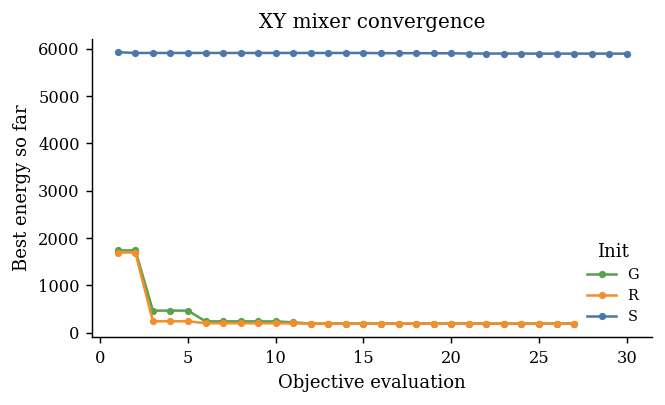

,init,mixer,valid_probability,opt_probability,expected_valid_gap_percent,energy,time_sec
0,S,xy,0.00034,0.00002,14.23709,5898.22175,126.01668
1,G,xy,1.00000,0.00000,28.03402,189.64389,7.55521
2,R,xy,1.00000,0.00000,27.79774,189.29390,7.66286


In [24]:
# Convergence traces for S/G/R using the XY mixer

from scipy.optimize import minimize

CONV_MIXER = "xy"
CONV_MAXITER = 35
CONV_LAYERS = 1

CONV_INITS = {
    "S": None,
    "G": greedy_row["tour"],
    "R": random_row["tour"],
}


def init_to_one_hot(init_tour):
    return None if init_tour is None else fixed_start_one_hot_encoding(init_tour, start=START)


def run_qaoa_trace(init_label, init_tour, mixer=CONV_MIXER, layers=CONV_LAYERS, maxiter=CONV_MAXITER):
    qaoa = QAOA(
        tsp=tsp,
        layers=layers,
        initial_route=init_to_one_hot(init_tour),
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=mixer,
    )
    qaoa.build_HC()

    rng = np.random.default_rng(SEED)
    theta0 = np.concatenate([
        rng.uniform(0, 2 * np.pi, layers),
        rng.uniform(0, np.pi, layers),
    ])

    trace = []

    def objective(theta):
        energy = qaoa._energy(theta)
        trace.append(float(energy))
        return energy

    t0 = time.perf_counter()
    result = minimize(
        objective,
        theta0,
        method="COBYLA",
        options={"maxiter": maxiter},
    )
    runtime = time.perf_counter() - t0

    trace_df = pd.DataFrame({
        "eval": np.arange(1, len(trace) + 1),
        "energy": trace,
        "best_so_far": np.minimum.accumulate(trace),
        "init": init_label,
        "mixer": mixer,
    })

    summary = mixer_state_summary(qaoa, result.x, best_known)
    summary.update({
        "init": init_label,
        "mixer": mixer,
        "energy": float(result.fun),
        "time_sec": runtime,
        "expected_valid_gap_percent": 100 * (summary["expected_valid_cost"] - best_known) / best_known,
    })

    return trace_df, summary


trace_frames = []
xy_summary_rows = []

for init_label, init_tour in CONV_INITS.items():
    print(f"Tracing init={init_label}, mixer={CONV_MIXER} ...")
    trace_df, summary = run_qaoa_trace(init_label, init_tour)
    trace_frames.append(trace_df)
    xy_summary_rows.append(summary)

xy_trace_df = pd.concat(trace_frames, ignore_index=True)
xy_convergence_summary = pd.DataFrame(xy_summary_rows)

fig, ax = plt.subplots(figsize=(5.0, 3.0), constrained_layout=True)
colors = {"S": "#4c78a8", "G": "#59a14f", "R": "#f28e2b"}

for init_label, sub in xy_trace_df.groupby("init"):
    ax.plot(
        sub["eval"],
        sub["best_so_far"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        color=colors[init_label],
        label=init_label,
    )

ax.set_title("XY mixer convergence")
ax.set_xlabel("Objective evaluation")
ax.set_ylabel("Best energy so far")
ax.legend(frameon=False, title="Init")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

display(
    xy_convergence_summary[
        ["init", "mixer", "valid_probability", "opt_probability", "expected_valid_gap_percent", "energy", "time_sec"]
    ].round(5)
)


Running init=S, mixer=grover ...
Running init=S, mixer=x ...
Running init=S, mixer=xy ...
Running init=G, mixer=grover ...
Running init=G, mixer=x ...
Running init=G, mixer=xy ...
Running init=R, mixer=grover ...
Running init=R, mixer=x ...
Running init=R, mixer=xy ...


,init,mixer,valid_prob_%,invalid_prob_%,opt_prob_%,expected_valid_gap_%,sampled_valid_%,sampled_best_cost,energy,time_sec
3,G,grover,100.0000,0.0000,100.0000,-0.0000,100.0,148.1199,148.1199,134.8069
4,G,x,99.9729,0.0271,99.9729,0.0000,100.0,148.1199,148.3117,100.2218
5,G,xy,99.9901,0.0099,0.0000,28.0340,100.0,189.6439,189.7061,5.5546
6,R,grover,100.0000,0.0000,0.0000,27.7977,100.0,189.2939,189.2939,134.7408
7,R,x,99.9953,0.0047,0.0000,27.7977,100.0,189.2939,189.3265,100.7037
8,R,xy,99.9986,0.0014,0.0000,27.7977,100.0,189.2939,189.3026,5.8762
0,S,grover,0.0366,99.9634,0.0030,15.9682,0.0,inf,5919.7365,136.3286
1,S,x,0.1513,99.8487,0.0108,13.8572,0.0,inf,4695.0085,101.1163
2,S,xy,0.0321,99.9679,0.0002,13.5267,0.0,inf,5905.8306,101.3862


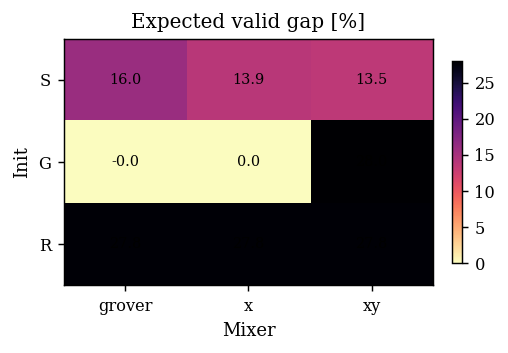

In [25]:
# Compact table for all mixer/init combinations

GRID_LAYERS = 1
GRID_MAXITER = 20
GRID_SHOTS = 200

GRID_MIXERS = ["grover", "x", "xy"]
GRID_INITS = {
    "S": None,
    "G": greedy_row["tour"],
    "R": random_row["tour"],
}


def run_grid_case(init_label, init_tour, mixer):
    qaoa = QAOA(
        tsp=tsp,
        layers=GRID_LAYERS,
        initial_route=init_to_one_hot(init_tour),
        seed=SEED,
        fixed_start=True,
        compressed_basis=False,
        mixer=mixer,
    )
    qaoa.build_HC()

    t0 = time.perf_counter()
    result = qaoa._optimize(maxiter=GRID_MAXITER, shots=GRID_SHOTS)
    runtime = time.perf_counter() - t0

    summary = mixer_state_summary(qaoa, result["theta"], best_known)

    return {
        "init": init_label,
        "mixer": mixer,
        "valid_prob_%": 100 * summary["valid_probability"],
        "invalid_prob_%": 100 * summary["invalid_probability"],
        "opt_prob_%": 100 * summary["opt_probability"],
        "expected_valid_gap_%": 100 * (summary["expected_valid_cost"] - best_known) / best_known,
        "sampled_valid_%": 100 * result["valid_fraction"],
        "sampled_best_cost": result["best_cost"],
        "energy": result["energy"],
        "time_sec": runtime,
    }


grid_rows = []

for init_label, init_tour in GRID_INITS.items():
    for mixer in GRID_MIXERS:
        print(f"Running init={init_label}, mixer={mixer} ...")
        grid_rows.append(run_grid_case(init_label, init_tour, mixer))

mixer_init_table = pd.DataFrame(grid_rows).sort_values(["init", "mixer"])
display(mixer_init_table.round(4))

# Optional map view: lower expected gap is better.
gap_map = (
    mixer_init_table
    .pivot(index="init", columns="mixer", values="expected_valid_gap_%")
    .loc[["S", "G", "R"], GRID_MIXERS]
)

fig, ax = plt.subplots(figsize=(3.8, 2.6), constrained_layout=True)
im = ax.imshow(gap_map.to_numpy(), cmap="magma_r", aspect="auto")
ax.set_xticks(range(len(gap_map.columns)), gap_map.columns)
ax.set_yticks(range(len(gap_map.index)), gap_map.index)
ax.set_xlabel("Mixer")
ax.set_ylabel("Init")
ax.set_title("Expected valid gap [%]")

for i in range(gap_map.shape[0]):
    for j in range(gap_map.shape[1]):
        ax.text(j, i, f"{gap_map.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.82)
plt.show()


# QAOA Playground

A compact set of extra figures for the classical/statevector QAOA part. These sweeps use the compressed valid-route basis so that we can cheaply compare different initial tours, QAOA depths, and route-basis mixers without exploding the full binary state space.

### Reading the playground

The playground is meant to generate candidate figures, not all of them should go in the paper. The heatmaps show which initialization/mixer combinations give low gap; the Pareto plot asks whether lower expected gap costs more runtime; the depth plot asks whether larger QAOA depth helps; the entropy and ranked-probability plots show whether QAOA concentrates on a few tours or remains diffuse; the mixer adjacency/connectivity plots explain how the chosen route-basis mixer moves through the valid-tour graph; the trace plot shows optimizer progress; the angle plot shows the learned QAOA parameters; the edge heatmap translates the QAOA probability distribution into likely directed tour edges.

For paper figures, keep only axis labels and units inside the plot. Put explanations such as marker size, dashed reference lines, and abbreviations in the caption or markdown discussion.

In [26]:
from scipy.optimize import minimize

PLAY_QAOA_MAXITER = 14
PLAY_QAOA_SHOTS = 300
PLAY_QAOA_LAYERS = [1, 2, 3]
PLAY_QAOA_SEEDS = list(range(10))

PLOT_DIR = Path("comparison_plots")
PLOT_DIR.mkdir(exist_ok=True)


def latex_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)
    return ax


def savefig(name):
    path = PLOT_DIR / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(path)


def route_label(route):
    return "-".join(map(str, route))


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p))) if len(p) else 0.0


def qaoa_probabilities_for_result(qaoa, result):
    if result.get("compressed_basis", False):
        state = qaoa._compressed_state(result["theta"])
        probabilities = np.abs(state) ** 2
        probabilities = probabilities / probabilities.sum()
        rows = []
        for idx, prob in enumerate(probabilities[:qaoa.compressed_valid_dimension]):
            tour = qaoa.compressed_routes[idx]
            rows.append({
                "idx": idx,
                "tour": route_label(tour),
                "tour_tuple": tuple(tour),
                "cost": float(qaoa.compressed_costs[idx]),
                "probability": float(prob),
                "valid": True,
            })
        return pd.DataFrame(rows)
    return pd.DataFrame()


def run_compressed_qaoa_experiment(name, init_tour, layers=1, moves=("swap", "two_opt"), depth=1, scope="all_valid", seed=SEED, maxiter=PLAY_QAOA_MAXITER):
    initial = fixed_start_one_hot_encoding(init_tour, start=START)
    qaoa = QAOA(
        tsp=tsp,
        layers=layers,
        initial_route=initial,
        seed=seed,
        fixed_start=True,
        compressed_basis=True,
        neighborhood_depth=depth,
        neighborhood_moves=moves,
        compressed_basis_scope=scope,
        pad_compressed_basis=True,
    )
    t0 = time.perf_counter()
    result = qaoa._optimize(maxiter=maxiter, shots=PLAY_QAOA_SHOTS)
    runtime = time.perf_counter() - t0
    probs = qaoa_probabilities_for_result(qaoa, result)
    expected_cost = float(np.dot(probs["probability"], probs["cost"])) if len(probs) else np.nan
    opt_prob = float(probs.loc[np.isclose(probs["cost"], best_known), "probability"].sum()) if len(probs) else np.nan
    top_prob = float(probs["probability"].max()) if len(probs) else np.nan
    return {
        "name": name,
        "init": name.split("/")[0],
        "layers": layers,
        "mixer": "+".join(moves),
        "moves": tuple(moves),
        "depth": depth,
        "scope": scope,
        "seed": seed,
        "time_sec": runtime,
        "energy": float(result["energy"]),
        "expected_cost": expected_cost,
        "best_cost": float(result["best_cost"]),
        "gap_percent": 100 * (float(result["best_cost"]) - best_known) / best_known,
        "expected_gap_percent": 100 * (expected_cost - best_known) / best_known,
        "opt_probability": opt_prob,
        "top_probability": top_prob,
        "entropy_bits": entropy(probs["probability"]),
        "valid_fraction": float(result["valid_fraction"]),
        "basis_dim": int(result["compressed_dimension"]),
        "valid_basis_dim": int(result["compressed_valid_dimension"]),
        "unused_states": int(result["compressed_unused_states"]),
        "nfev": getattr(result["optimizer_result"], "nfev", np.nan),
        "tour": route_label(result["best_tour"]),
        "theta": result["theta"],
        "gammas": result["gammas"],
        "betas": result["betas"],
        "probabilities": probs,
        "qaoa": qaoa,
    }


def optimize_compressed_with_trace(init_tour, layers=2, moves=("swap", "two_opt"), depth=1, scope="all_valid", seed=SEED, maxiter=PLAY_QAOA_MAXITER):
    initial = fixed_start_one_hot_encoding(init_tour, start=START)
    qaoa = QAOA(
        tsp=tsp,
        layers=layers,
        initial_route=initial,
        seed=seed,
        fixed_start=True,
        compressed_basis=True,
        neighborhood_depth=depth,
        neighborhood_moves=moves,
        compressed_basis_scope=scope,
    )
    qaoa.build_compressed_basis()
    rng = np.random.default_rng(seed)
    x0 = np.concatenate([rng.uniform(0, 2 * np.pi, layers), rng.uniform(0, np.pi, layers)])
    trace = []

    def objective(theta):
        value = qaoa._compressed_energy(theta)
        trace.append(float(value))
        return value

    result = minimize(objective, x0, method="COBYLA", options={"maxiter": maxiter})
    measurement = qaoa._compressed_measure(result.x, shots=PLAY_QAOA_SHOTS)
    return qaoa, result, measurement, pd.DataFrame({"eval": np.arange(1, len(trace) + 1), "energy": trace})


In [27]:
# Build a small but varied QAOA experiment table.
init_tours = {
    "G": greedy_row["tour"],
    "R": random_row["tour"],
    "HK": held_karp_row["tour"],
}

mixer_specs = {
    "S": ("swap",),
    "2O": ("two_opt",),
    "S+2O": ("swap", "two_opt"),
}

experiment_rows = []
for init_name, init_tour in init_tours.items():
    for mixer_name, moves in mixer_specs.items():
        for layers in PLAY_QAOA_LAYERS:
            row = run_compressed_qaoa_experiment(
                f"{init_name}/{mixer_name}/p{layers}",
                init_tour,
                layers=layers,
                moves=moves,
                depth=1,
                scope="all_valid",
                seed=SEED + 17 * layers + len(moves),
            )
            row["mixer_short"] = mixer_name
            experiment_rows.append(row)

qaoa_play = pd.DataFrame([{k: v for k, v in row.items() if k not in {"probabilities", "qaoa"}} for row in experiment_rows])
qaoa_play["label"] = qaoa_play["init"] + "/" + qaoa_play["mixer_short"] + "/p" + qaoa_play["layers"].astype(str)
qaoa_play.sort_values(["gap_percent", "expected_gap_percent", "time_sec"], inplace=True)

summary_cols = ["label", "best_cost", "gap_percent", "expected_gap_percent", "opt_probability", "entropy_bits", "time_sec", "basis_dim", "valid_fraction"]
display(qaoa_play[summary_cols].round(5).head(15))


,label,best_cost,gap_percent,expected_gap_percent,opt_probability,entropy_bits,time_sec,basis_dim,valid_fraction
21,HK/2O/p1,148.11991,0.0,0.00210,0.99984,0.00322,0.01049,32,1.0
3,G/2O/p1,148.11991,0.0,0.00210,0.99984,0.00322,0.01151,32,1.0
18,HK/S/p1,148.11991,0.0,0.02320,0.99795,0.02663,0.01011,32,1.0
0,G/S/p1,148.11991,0.0,0.02320,0.99795,0.02663,0.01264,32,1.0
8,G/S+2O/p3,148.11991,0.0,5.09423,0.63713,2.60551,0.00941,32,1.0
26,HK/S+2O/p3,148.11991,0.0,5.09423,0.63713,2.60551,0.00956,32,1.0
25,HK/S+2O/p2,148.11991,0.0,5.12898,0.66294,2.27876,0.01019,32,1.0
7,G/S+2O/p2,148.11991,0.0,5.12898,0.66294,2.27876,0.01043,32,1.0
23,HK/2O/p3,148.11991,0.0,7.83961,0.41971,3.44703,0.00835,32,1.0
5,G/2O/p3,148.11991,0.0,7.83961,0.41971,3.44703,0.00915,32,1.0


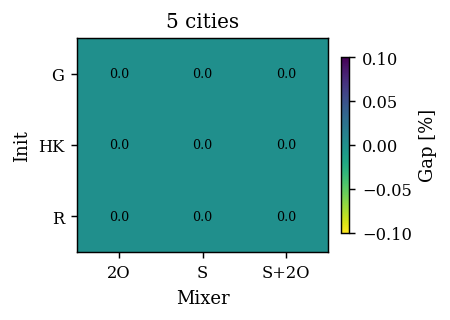

In [28]:
# 1. QAOA gap heatmap: initialization versus mixer, best over p.
pivot = qaoa_play.groupby(["init", "mixer_short"])["gap_percent"].min().unstack()
fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)
im = ax.imshow(pivot.to_numpy(), cmap="viridis_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("Mixer")
ax.set_ylabel("Init")
ax.set_title(f"{N_CITIES} cities")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7, color="white" if pivot.iloc[i, j] > pivot.to_numpy().mean() else "black")
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Gap [%]")
plt.show()

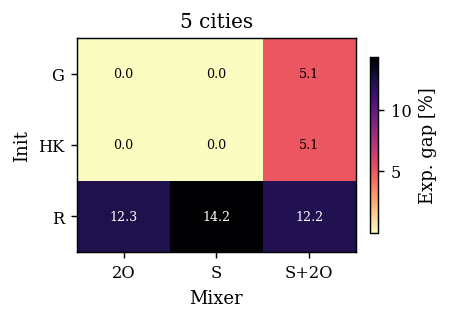

In [29]:
# 2. Expected QAOA gap heatmap: where probability mass sits, not only sampled best.
pivot = qaoa_play.groupby(["init", "mixer_short"])["expected_gap_percent"].min().unstack()
fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)
im = ax.imshow(pivot.to_numpy(), cmap="magma_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("Mixer")
ax.set_ylabel("Init")
ax.set_title(f"{N_CITIES} cities")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7, color="white" if pivot.iloc[i, j] > pivot.to_numpy().mean() else "black")
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Exp. gap [%]")
plt.show()

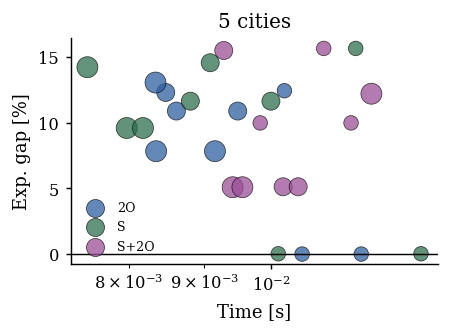

In [30]:
# 3. Runtime/gap Pareto map.
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
colors = {"S": "#2f6f4e", "2O": "#2f5f9f", "S+2O": "#9b4f96"}
for mixer, sub in qaoa_play.groupby("mixer_short"):
    ax.scatter(sub["time_sec"], sub["expected_gap_percent"], s=30 + 35 * sub["layers"], color=colors[mixer], alpha=0.75, edgecolor="black", linewidth=0.4, label=mixer)
ax.set_xscale("log")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Exp. gap [%]")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

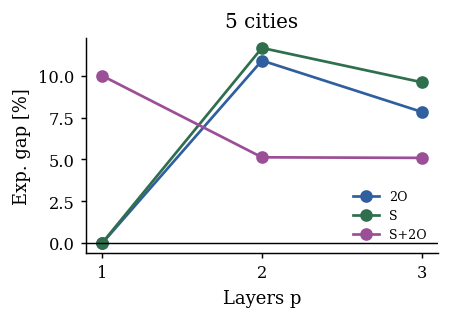

In [31]:
# 4. QAOA depth sweep.
best_by_depth = qaoa_play.groupby(["layers", "mixer_short"], as_index=False)["expected_gap_percent"].min()
fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)
for mixer, sub in best_by_depth.groupby("mixer_short"):
    ax.plot(sub["layers"], sub["expected_gap_percent"], marker="o", linewidth=1.5, color=colors[mixer], label=mixer)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(PLAY_QAOA_LAYERS)
ax.set_xlabel("Layers p")
ax.set_ylabel("Exp. gap [%]")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

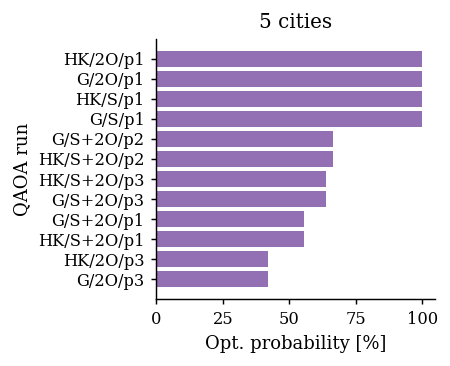

In [32]:
# 5. Probability of the Held-Karp optimum.
fig, ax = plt.subplots(figsize=(3.35, 2.7), constrained_layout=True)
show = qaoa_play.sort_values("opt_probability", ascending=True).tail(12)
ax.barh(show["label"], 100 * show["opt_probability"], color="#7b4fa3", alpha=0.82)
ax.set_xlabel("Opt. probability [%]")
ax.set_ylabel("QAOA run")
ax.set_title(f"{N_CITIES} cities")
latex_axes(ax)
plt.show()

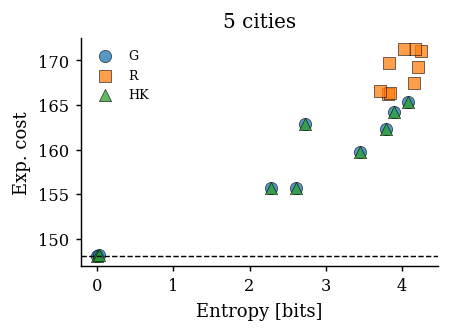

In [33]:
# 6. Entropy versus expected cost.
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
for init, marker in {"G": "o", "R": "s", "HK": "^"}.items():
    sub = qaoa_play[qaoa_play["init"] == init]
    ax.scatter(sub["entropy_bits"], sub["expected_cost"], s=46, marker=marker, alpha=0.75, edgecolor="black", linewidth=0.4, label=init)
ax.axhline(best_known, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Entropy [bits]")
ax.set_ylabel("Exp. cost")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

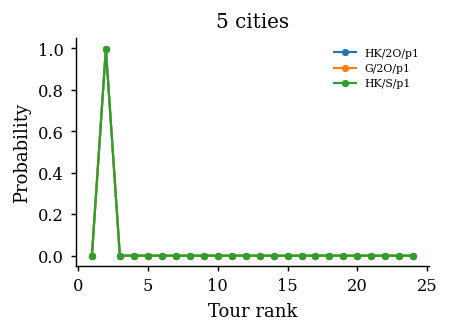

In [34]:
# 7. Probability over ranked tours for the three best QAOA runs.
best_labels = qaoa_play.head(3)["label"].tolist()
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
for label in best_labels:
    idx = qaoa_play.index[qaoa_play["label"] == label][0]
    probs = experiment_rows[idx]["probabilities"].sort_values("cost").reset_index(drop=True)
    probs["rank"] = np.arange(1, len(probs) + 1)
    ax.plot(probs["rank"], probs["probability"], marker="o", markersize=3, linewidth=1.2, label=label)
ax.set_xlabel("Tour rank")
ax.set_ylabel("Probability")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=6)
latex_axes(ax)
plt.show()

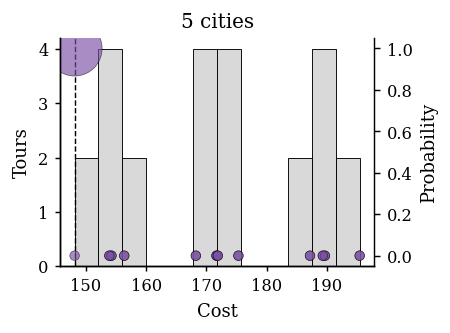

In [35]:
# 8. Cost spectrum with QAOA probability overlay.
best_idx = qaoa_play.index[0]
best_probs = experiment_rows[best_idx]["probabilities"].copy()
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
ax.hist(landscape["cost"], bins=min(12, len(landscape)), color="#d9d9d9", edgecolor="black", linewidth=0.5, label="Tours")
ax2 = ax.twinx()
ax2.scatter(best_probs["cost"], best_probs["probability"], s=28 + 900 * best_probs["probability"], color="#7b4fa3", alpha=0.65, edgecolor="black", linewidth=0.35, label="QAOA")
ax.axvline(best_known, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Cost")
ax.set_ylabel("Tours")
ax2.set_ylabel("Probability")
ax.set_title(f"{N_CITIES} cities")
latex_axes(ax)
ax2.spines["top"].set_visible(False)
plt.show()

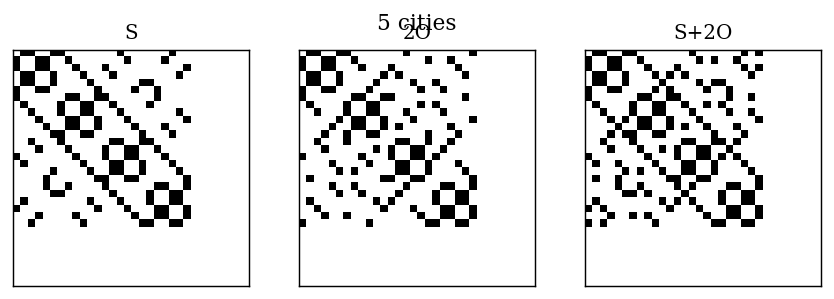

In [36]:
# 9. Mixer adjacency patterns in valid-route basis.
fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.1), constrained_layout=True)
for ax, (mixer_name, moves) in zip(axes, mixer_specs.items()):
    q = QAOA(tsp=tsp, layers=1, initial_route=fixed_start_one_hot_encoding(greedy_row["tour"], start=START), seed=SEED, fixed_start=True, compressed_basis=True, neighborhood_moves=moves, compressed_basis_scope="all_valid")
    q.build_compressed_basis()
    matrix = (q.compressed_mixer != 0).astype(int)
    np.fill_diagonal(matrix, 0)
    ax.imshow(matrix, cmap="Greys", aspect="equal")
    ax.set_title(mixer_name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"{N_CITIES} cities", y=1.02)
plt.show()

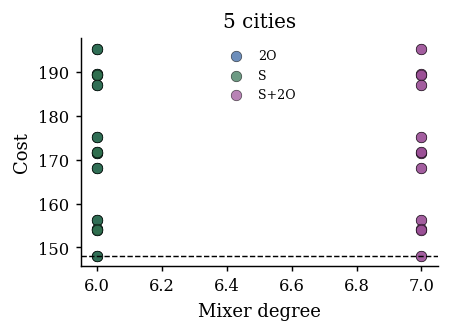

In [37]:
# 10. Mixer connectivity versus cost.
conn_rows = []
for mixer_name, moves in mixer_specs.items():
    q = QAOA(tsp=tsp, layers=1, initial_route=fixed_start_one_hot_encoding(greedy_row["tour"], start=START), seed=SEED, fixed_start=True, compressed_basis=True, neighborhood_moves=moves, compressed_basis_scope="all_valid")
    q.build_compressed_basis()
    degree = (q.compressed_mixer[:q.compressed_valid_dimension, :q.compressed_valid_dimension] != 0).sum(axis=1) - (np.diag(q.compressed_mixer[:q.compressed_valid_dimension, :q.compressed_valid_dimension]) != 0).astype(int)
    for cost, deg in zip(q.compressed_valid_costs, degree):
        conn_rows.append({"mixer": mixer_name, "cost": cost, "degree": deg})
conn = pd.DataFrame(conn_rows)
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
for mixer, sub in conn.groupby("mixer"):
    ax.scatter(sub["degree"], sub["cost"], s=34, color=colors[mixer], alpha=0.7, edgecolor="black", linewidth=0.35, label=mixer)
ax.axhline(best_known, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Mixer degree")
ax.set_ylabel("Cost")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

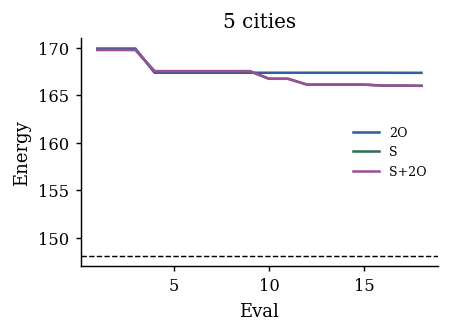

In [38]:
# 11. Optimization traces for different mixers.
trace_rows = []
for mixer_name, moves in mixer_specs.items():
    _, _, _, trace_df = optimize_compressed_with_trace(greedy_row["tour"], layers=2, moves=moves, scope="all_valid", seed=SEED + 3, maxiter=18)
    trace_df["mixer"] = mixer_name
    trace_rows.append(trace_df)
qaoa_traces = pd.concat(trace_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
for mixer, sub in qaoa_traces.groupby("mixer"):
    best_so_far = sub["energy"].cummin()
    ax.plot(sub["eval"], best_so_far, linewidth=1.4, color=colors[mixer], label=mixer)
ax.axhline(best_known, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Eval")
ax.set_ylabel("Energy")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

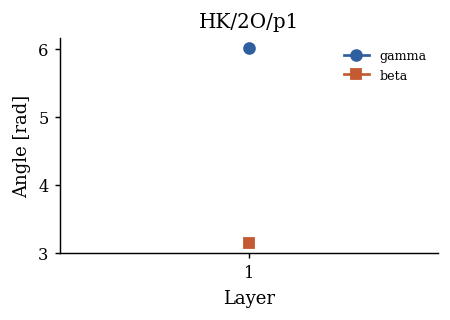

In [39]:
# 12. Learned QAOA angles for the best run.
best = qaoa_play.iloc[0]
angles = pd.DataFrame({"layer": np.arange(1, int(best["layers"]) + 1), "gamma": best["gammas"], "beta": best["betas"]})
fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)
ax.plot(angles["layer"], angles["gamma"], marker="o", color="#2f5f9f", label="gamma")
ax.plot(angles["layer"], angles["beta"], marker="s", color="#c45a32", label="beta")
ax.set_xticks(angles["layer"])
ax.set_xlabel("Layer")
ax.set_ylabel("Angle [rad]")
ax.set_title(best["label"])
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

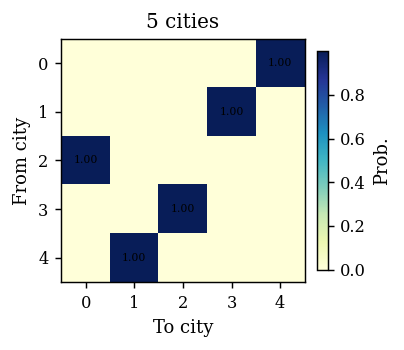

In [40]:
# 13. Edge probability heatmap from the best QAOA distribution.
def edge_probability_matrix(prob_df):
    mat = np.zeros((N_CITIES, N_CITIES))
    for _, row in prob_df.iterrows():
        tour = list(row["tour_tuple"])
        for a, b in zip(tour[:-1], tour[1:]):
            mat[a, b] += row["probability"]
    return mat

edge_mat = edge_probability_matrix(best_probs)
fig, ax = plt.subplots(figsize=(3.0, 2.65), constrained_layout=True)
im = ax.imshow(edge_mat, cmap="YlGnBu", vmin=0)
ax.set_xticks(range(N_CITIES), range(N_CITIES))
ax.set_yticks(range(N_CITIES), range(N_CITIES))
ax.set_xlabel("To city")
ax.set_ylabel("From city")
ax.set_title(f"{N_CITIES} cities")
for i in range(N_CITIES):
    for j in range(N_CITIES):
        if edge_mat[i, j] > 0.02:
            ax.text(j, i, f"{edge_mat[i, j]:.2f}", ha="center", va="center", fontsize=6)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Prob.")
plt.show()

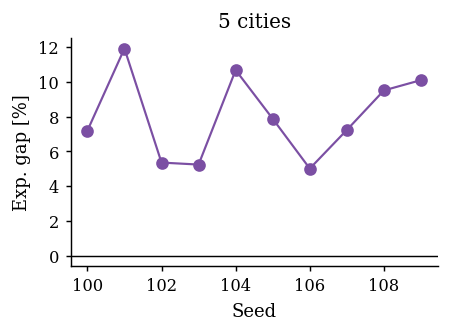

,seed,best_cost,gap_percent,expected_gap_percent,opt_probability,time_sec,entropy_bits
0,100,148.11991,0.0,7.18979,0.56281,0.00862,3.03316
1,101,148.11991,0.0,11.91580,0.15397,0.00582,3.90807
2,102,148.11991,0.0,5.35551,0.70642,0.00684,2.47010
3,103,148.11991,0.0,5.24091,0.72574,0.00753,2.11802
4,104,148.11991,0.0,10.67522,0.44589,0.00716,3.55289
5,105,148.11991,0.0,7.87475,0.54461,0.00574,3.03474
6,106,148.11991,0.0,5.01089,0.70187,0.00628,2.19784
7,107,148.11991,0.0,7.23184,0.49345,0.00718,3.46192
8,108,148.11991,0.0,9.50637,0.40254,0.00743,3.34871
9,109,148.11991,0.0,10.09921,0.36684,0.00625,3.70156


In [41]:
# 14. QAOA seed sensitivity for one configuration.
seed_rows = []
for seed in PLAY_QAOA_SEEDS:
    row = run_compressed_qaoa_experiment("G/S+2O/p2", greedy_row["tour"], layers=2, moves=("swap", "two_opt"), scope="all_valid", seed=100 + seed, maxiter=10)
    seed_rows.append({k: row[k] for k in ["seed", "best_cost", "gap_percent", "expected_gap_percent", "opt_probability", "time_sec", "entropy_bits"]})
qaoa_seed_df = pd.DataFrame(seed_rows)
fig, ax = plt.subplots(figsize=(3.35, 2.45), constrained_layout=True)
ax.plot(qaoa_seed_df["seed"], qaoa_seed_df["expected_gap_percent"], marker="o", color="#7b4fa3", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Exp. gap [%]")
ax.set_title(f"{N_CITIES} cities")
latex_axes(ax)
plt.show()
display(qaoa_seed_df.round(5))

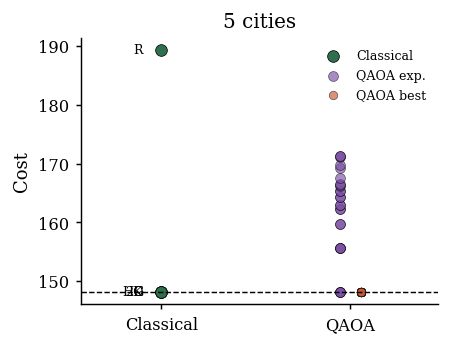

In [42]:
# 15. Classical versus QAOA cost distribution.
classical_points = pd.DataFrame([
    {"method": "G", "cost": greedy_row["cost"]},
    {"method": "R", "cost": random_row["cost"]},
    {"method": "2O", "cost": two_opt_row["cost"]},
    {"method": "HK", "cost": held_karp_row["cost"]},
])
qaoa_cost_samples = qaoa_play[["label", "expected_cost", "best_cost"]].copy()
fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
ax.scatter(np.zeros(len(classical_points)), classical_points["cost"], s=42, color="#2f6f4e", edgecolor="black", linewidth=0.4, label="Classical")
for _, row in classical_points.iterrows():
    ax.annotate(row["method"], (0, row["cost"]), xytext=(-10, 0), textcoords="offset points", ha="right", va="center", fontsize=7)
ax.scatter(np.ones(len(qaoa_cost_samples)), qaoa_cost_samples["expected_cost"], s=30, color="#7b4fa3", alpha=0.65, edgecolor="black", linewidth=0.35, label="QAOA exp.")
ax.scatter(np.full(len(qaoa_cost_samples), 1.12), qaoa_cost_samples["best_cost"], s=22, color="#c45a32", alpha=0.65, edgecolor="black", linewidth=0.35, label="QAOA best")
ax.axhline(best_known, color="black", linestyle="--", linewidth=0.8)
ax.set_xlim(-0.45, 1.55)
ax.set_xticks([0, 1.06], ["Classical", "QAOA"])
ax.set_ylabel("Cost")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()

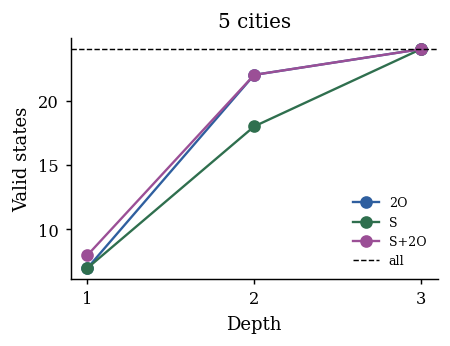

,scope,depth,mixer,valid,dim,unused
0,local,1,S,7,8,1
1,local,1,2O,7,8,1
2,local,1,S+2O,8,8,0
3,local,2,S,18,32,14
4,local,2,2O,22,32,10
5,local,2,S+2O,22,32,10
6,local,3,S,24,32,8
7,local,3,2O,24,32,8
8,local,3,S+2O,24,32,8
9,all_valid,1,S,24,32,8


In [43]:
# 16. Route-basis size and padding overhead.
basis_rows = []
for scope in ["local", "all_valid"]:
    for depth in [1, 2, 3]:
        for mixer_name, moves in mixer_specs.items():
            q = QAOA(tsp=tsp, layers=1, initial_route=fixed_start_one_hot_encoding(greedy_row["tour"], start=START), seed=SEED, fixed_start=True, compressed_basis=True, neighborhood_depth=depth, neighborhood_moves=moves, compressed_basis_scope=scope)
            q.build_compressed_basis()
            basis_rows.append({"scope": scope, "depth": depth, "mixer": mixer_name, "valid": q.compressed_valid_dimension, "dim": q.compressed_dimension, "unused": q.compressed_unused_states})
basis_df = pd.DataFrame(basis_rows)
fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
sub = basis_df[basis_df["scope"] == "local"]
for mixer, grp in sub.groupby("mixer"):
    ax.plot(grp["depth"], grp["valid"], marker="o", linewidth=1.3, color=colors[mixer], label=mixer)
ax.axhline(math.factorial(N_CITIES - 1), color="black", linestyle="--", linewidth=0.8, label="all")
ax.set_xticks([1, 2, 3])
ax.set_xlabel("Depth")
ax.set_ylabel("Valid states")
ax.set_title(f"{N_CITIES} cities")
ax.legend(frameon=False, fontsize=7)
latex_axes(ax)
plt.show()
display(basis_df)